# Описание датасета и задания

Необходимо проанализировать цену и популярность (выраженную в
количестве продаж) персональных компьютеров, а также выявить зависимость
этих показателей от комплектующих (датасет wb_pc_hard.csv) ADVANCED
Дополнительно для специалистов по ML: построить регрессионную
модель для предсказания стоимости компьютеров.

**Карточка проекта**

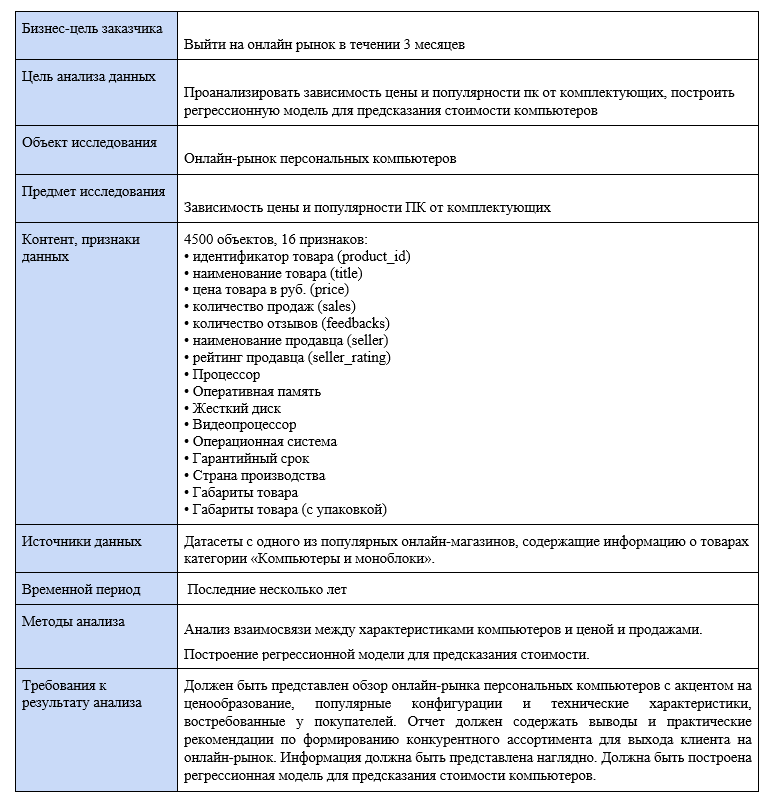


# Импорт

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
from scipy import stats
from matplotlib import style
style.use('seaborn-v0_8')

In [ ]:
!pip install feature_engine

In [ ]:
!pip install category_encoders

# Подгрузка датасета

In [ ]:
!pip install --upgrade gdown

In [ ]:
!gdown --id 1jxZgaVZZkHhl1GijufqU-muXdB6HMNkY

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1jxZgaVZZkHhl1GijufqU-muXdB6HMNkY
To: /content/wb_pc_hard.csv
100% 3.97M/3.97M [00:00<00:00, 55.3MB/s]


In [ ]:
df = pd.read_csv('wb_pc_hard.csv')
df_copy = df.copy()

# Обзор датасета

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_id                     4500 non-null   int64  
 1   title                          4500 non-null   object 
 2   price                          4499 non-null   object 
 3   sales                          1164 non-null   object 
 4   feedbacks                      4500 non-null   object 
 5   seller                         4391 non-null   object 
 6   seller_rating                  4389 non-null   float64
 7   Процессор                      4500 non-null   object 
 8   Оперативная память             4500 non-null   object 
 9   Жесткий диск                   4500 non-null   object 
 10  Видеопроцессор                 4500 non-null   object 
 11  Операционная система           4500 non-null   object 
 12  Гарантийный срок               2648 non-null   o

Пустые значения в price (одно), sales, seller, seller_rating, гарантийный срок, страна производства.

In [ ]:
df.head()

,product_id,title,price,sales,feedbacks,seller,seller_rating,Процессор,Оперативная память,Жесткий диск,Видеопроцессор,Операционная система,Гарантийный срок,Страна производства,Габариты товара,Габариты товара (с упаковкой)
0,10148385,Системный блок OFFICE 120 WB 0710623 J1800/4Gb...,10805₽,Купили более 400 раз,7 отзывов,NaN,NaN,"{'Процессор_тип': 'Intel Celeron', 'Количество...","{'Тип оперативной памяти': 'DDR 3', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",Intel HD Graphics,отсутствует,3года,Россия,"{'Ширина предмета': '28.5 см', 'Глубина предме...","{'Длина упаковки': '43.5 см', 'Ширина упаковки..."
1,17877962,Системный блок,32900₽,NaN,0 отзывов,NaN,NaN,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'не заполнено', 'Об...","{'Объем накопителя HDD': None, 'Объем накопите...",не заполнено,отсутствует,NaN,Китай,"{'Ширина предмета': None, 'Глубина предмета': ...","{'Длина упаковки': '43 см', 'Ширина упаковки':..."
2,17880420,Компьютер Hp Prodesk 400 g6 mt,35720₽,NaN,0 отзывов,NaN,NaN,"{'Процессор_тип': 'не заполнено', 'Количество ...","{'Тип оперативной памяти': 'не заполнено', 'Об...","{'Объем накопителя HDD': None, 'Объем накопите...",не заполнено,отсутствует,NaN,NaN,"{'Ширина предмета': None, 'Глубина предмета': ...","{'Длина упаковки': None, 'Ширина упаковки': No..."
3,19347937,Офисный Компьютер Robotcomp Казначей V1,39237₽,Купили более 10 раз,1 отзыв,Robotcomp,4.7,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",Intel UHD Graphics 630,windows пробная,3 Года (36 месяцев),Россия,"{'Ширина предмета': '28 см', 'Глубина предмета...","{'Длина упаковки': '60 см', 'Ширина упаковки':..."
4,19348951,Игровой Компьютер Robotcomp М16 2.0 V1,76188₽,Купили более 200 раз,94 отзыва,Robotcomp,4.7,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",NVIDIA GeForce GTX 1660,windows пробная,3 Года (36 месяцев),Россия,"{'Ширина предмета': '20 см', 'Глубина предмета...","{'Длина упаковки': '50 см', 'Ширина упаковки':..."


**Что можно сделать**
* Разложить вложенные значения по отдельным столбцам.
*   Перевести в числовые значения: price, sales, feedbacks, гарантийный срок (+ значения, полученные из вложенных).
*   Обработать пропуски + значения вида "не заполнено" (возможно такие значения не нужно обрабатывать и наличие характеристики будет являться важным критерием, который повлияет на цену и популярность).
*   Обработать дубликаты
* Что касается лишних признаков: возможно не имеют значения для анализа признаки "title", "габариты товара (с упаковкой)" (уже есть габариты без упаковки), product_id.




# Предобработка данных

## Обработка вложенных значений

Вложенные значения содержат: оперативная память, жесткий диск, габариты товара, габариты товара (с упаковкой).

### Процессор

In [ ]:
df_copy['Процессор'][0]

"{'Процессор_тип': 'Intel Celeron', 'Количество ядер процессора': '2'}"

In [ ]:
df_copy['Тип процессора'] = df_copy['Процессор'].apply(lambda x: eval(x)['Процессор_тип'])

In [ ]:
df_copy['Количество ядер процессора'] = df_copy['Процессор'].apply(lambda x: eval(x)['Количество ядер процессора'])

In [ ]:
df_copy.head()

,product_id,title,price,sales,feedbacks,seller,seller_rating,Процессор,Оперативная память,Жесткий диск,Видеопроцессор,Операционная система,Гарантийный срок,Страна производства,Габариты товара,Габариты товара (с упаковкой),Тип процессора,Количество ядер процессора
0,10148385,Системный блок OFFICE 120 WB 0710623 J1800/4Gb...,10805₽,Купили более 400 раз,7 отзывов,NaN,NaN,"{'Процессор_тип': 'Intel Celeron', 'Количество...","{'Тип оперативной памяти': 'DDR 3', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",Intel HD Graphics,отсутствует,3года,Россия,"{'Ширина предмета': '28.5 см', 'Глубина предме...","{'Длина упаковки': '43.5 см', 'Ширина упаковки...",Intel Celeron,2
1,17877962,Системный блок,32900₽,NaN,0 отзывов,NaN,NaN,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'не заполнено', 'Об...","{'Объем накопителя HDD': None, 'Объем накопите...",не заполнено,отсутствует,NaN,Китай,"{'Ширина предмета': None, 'Глубина предмета': ...","{'Длина упаковки': '43 см', 'Ширина упаковки':...",Intel Core i5,не заполнено
2,17880420,Компьютер Hp Prodesk 400 g6 mt,35720₽,NaN,0 отзывов,NaN,NaN,"{'Процессор_тип': 'не заполнено', 'Количество ...","{'Тип оперативной памяти': 'не заполнено', 'Об...","{'Объем накопителя HDD': None, 'Объем накопите...",не заполнено,отсутствует,NaN,NaN,"{'Ширина предмета': None, 'Глубина предмета': ...","{'Длина упаковки': None, 'Ширина упаковки': No...",не заполнено,не заполнено
3,19347937,Офисный Компьютер Robotcomp Казначей V1,39237₽,Купили более 10 раз,1 отзыв,Robotcomp,4.7,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",Intel UHD Graphics 630,windows пробная,3 Года (36 месяцев),Россия,"{'Ширина предмета': '28 см', 'Глубина предмета...","{'Длина упаковки': '60 см', 'Ширина упаковки':...",Intel Core i5,6
4,19348951,Игровой Компьютер Robotcomp М16 2.0 V1,76188₽,Купили более 200 раз,94 отзыва,Robotcomp,4.7,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",NVIDIA GeForce GTX 1660,windows пробная,3 Года (36 месяцев),Россия,"{'Ширина предмета': '20 см', 'Глубина предмета...","{'Длина упаковки': '50 см', 'Ширина упаковки':...",Intel Core i5,6


### Оперативная память

In [ ]:
df_copy['Оперативная память'][0]

"{'Тип оперативной памяти': 'DDR 3', 'Объем оперативной памяти (Гб)': '4 ГБ'}"

In [ ]:
df_copy['Тип оперативной памяти'] = df_copy['Оперативная память'].apply(lambda x: eval(x)['Тип оперативной памяти'])

In [ ]:
df_copy['Объем оперативной памяти (Гб)'] = df_copy['Оперативная память'].apply(lambda x: eval(x)['Объем оперативной памяти (Гб)'])

In [ ]:
df_copy.head()

,product_id,title,price,sales,feedbacks,seller,seller_rating,Процессор,Оперативная память,Жесткий диск,Видеопроцессор,Операционная система,Гарантийный срок,Страна производства,Габариты товара,Габариты товара (с упаковкой),Тип процессора,Количество ядер процессора,Тип оперативной памяти,Объем оперативной памяти (Гб)
0,10148385,Системный блок OFFICE 120 WB 0710623 J1800/4Gb...,10805₽,Купили более 400 раз,7 отзывов,NaN,NaN,"{'Процессор_тип': 'Intel Celeron', 'Количество...","{'Тип оперативной памяти': 'DDR 3', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",Intel HD Graphics,отсутствует,3года,Россия,"{'Ширина предмета': '28.5 см', 'Глубина предме...","{'Длина упаковки': '43.5 см', 'Ширина упаковки...",Intel Celeron,2,DDR 3,4 ГБ
1,17877962,Системный блок,32900₽,NaN,0 отзывов,NaN,NaN,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'не заполнено', 'Об...","{'Объем накопителя HDD': None, 'Объем накопите...",не заполнено,отсутствует,NaN,Китай,"{'Ширина предмета': None, 'Глубина предмета': ...","{'Длина упаковки': '43 см', 'Ширина упаковки':...",Intel Core i5,не заполнено,не заполнено,16 ГБ
2,17880420,Компьютер Hp Prodesk 400 g6 mt,35720₽,NaN,0 отзывов,NaN,NaN,"{'Процессор_тип': 'не заполнено', 'Количество ...","{'Тип оперативной памяти': 'не заполнено', 'Об...","{'Объем накопителя HDD': None, 'Объем накопите...",не заполнено,отсутствует,NaN,NaN,"{'Ширина предмета': None, 'Глубина предмета': ...","{'Длина упаковки': None, 'Ширина упаковки': No...",не заполнено,не заполнено,не заполнено,16 ГБ
3,19347937,Офисный Компьютер Robotcomp Казначей V1,39237₽,Купили более 10 раз,1 отзыв,Robotcomp,4.7,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",Intel UHD Graphics 630,windows пробная,3 Года (36 месяцев),Россия,"{'Ширина предмета': '28 см', 'Глубина предмета...","{'Длина упаковки': '60 см', 'Ширина упаковки':...",Intel Core i5,6,DDR 4,8
4,19348951,Игровой Компьютер Robotcomp М16 2.0 V1,76188₽,Купили более 200 раз,94 отзыва,Robotcomp,4.7,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",NVIDIA GeForce GTX 1660,windows пробная,3 Года (36 месяцев),Россия,"{'Ширина предмета': '20 см', 'Глубина предмета...","{'Длина упаковки': '50 см', 'Ширина упаковки':...",Intel Core i5,6,DDR 4,16


### Жесткий диск

Разделим на колонки "тип накопителя" и "объём накопителя".

In [ ]:
df_copy['Жесткий диск'][0]

"{'Объем накопителя HDD': None, 'Объем накопителя SSD': None}"

In [ ]:
# Функция для того, чтобы достать тип накопителя
def what_type(item):
  item = eval(item)
  if item['Объем накопителя HDD'] is not None:
    if 'нет' not in item['Объем накопителя HDD'] or '0' not in item['Объем накопителя HDD']:
      return 'HDD'
  if item['Объем накопителя SSD'] is not None:
    if 'нет' not in item['Объем накопителя SSD'] or '0' not in item['Объем накопителя SSD']:
      return 'SSD'
  return None

In [ ]:
df_copy['Тип накопителя'] = df_copy['Жесткий диск'].apply(what_type)

In [ ]:
df_copy['Тип накопителя'].value_counts()

,count
Тип накопителя,
SSD,2694
HDD,1333


In [ ]:
# Функция для того, чтобы достать объём накопителя
def what_v(item):
  item = eval(item)
  if item['Объем накопителя HDD'] is not None:
    if 'нет' not in item['Объем накопителя HDD'] or '0' not in item['Объем накопителя HDD']:
      return item['Объем накопителя HDD']
  if item['Объем накопителя SSD'] is not None:
    if 'нет' not in item['Объем накопителя SSD'] or '0' not in item['Объем накопителя SSD']:
      return item['Объем накопителя SSD']
  return 0

In [ ]:
df_copy['Объем накопителя'] = df_copy['Жесткий диск'].apply(what_v)

In [ ]:
df_copy['Объем накопителя'].value_counts()

,count
Объем накопителя,
1000 Гб,1391
0,473
480 ГБ,389
960 Гб,184
512 Гб,184
...,...
1500 гб,1
1500,1
256 гб; 960 гб,1


In [ ]:
df_copy.head()

,product_id,title,price,sales,feedbacks,seller,seller_rating,Процессор,Оперативная память,Жесткий диск,...,Гарантийный срок,Страна производства,Габариты товара,Габариты товара (с упаковкой),Тип процессора,Количество ядер процессора,Тип оперативной памяти,Объем оперативной памяти (Гб),Тип накопителя,Объем накопителя
0,10148385,Системный блок OFFICE 120 WB 0710623 J1800/4Gb...,10805₽,Купили более 400 раз,7 отзывов,NaN,NaN,"{'Процессор_тип': 'Intel Celeron', 'Количество...","{'Тип оперативной памяти': 'DDR 3', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",...,3года,Россия,"{'Ширина предмета': '28.5 см', 'Глубина предме...","{'Длина упаковки': '43.5 см', 'Ширина упаковки...",Intel Celeron,2,DDR 3,4 ГБ,None,0
1,17877962,Системный блок,32900₽,NaN,0 отзывов,NaN,NaN,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'не заполнено', 'Об...","{'Объем накопителя HDD': None, 'Объем накопите...",...,NaN,Китай,"{'Ширина предмета': None, 'Глубина предмета': ...","{'Длина упаковки': '43 см', 'Ширина упаковки':...",Intel Core i5,не заполнено,не заполнено,16 ГБ,SSD,256 Гб
2,17880420,Компьютер Hp Prodesk 400 g6 mt,35720₽,NaN,0 отзывов,NaN,NaN,"{'Процессор_тип': 'не заполнено', 'Количество ...","{'Тип оперативной памяти': 'не заполнено', 'Об...","{'Объем накопителя HDD': None, 'Объем накопите...",...,NaN,NaN,"{'Ширина предмета': None, 'Глубина предмета': ...","{'Длина упаковки': None, 'Ширина упаковки': No...",не заполнено,не заполнено,не заполнено,16 ГБ,SSD,512 Гб
3,19347937,Офисный Компьютер Robotcomp Казначей V1,39237₽,Купили более 10 раз,1 отзыв,Robotcomp,4.7,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",...,3 Года (36 месяцев),Россия,"{'Ширина предмета': '28 см', 'Глубина предмета...","{'Длина упаковки': '60 см', 'Ширина упаковки':...",Intel Core i5,6,DDR 4,8,SSD,480 ГБ
4,19348951,Игровой Компьютер Robotcomp М16 2.0 V1,76188₽,Купили более 200 раз,94 отзыва,Robotcomp,4.7,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",...,3 Года (36 месяцев),Россия,"{'Ширина предмета': '20 см', 'Глубина предмета...","{'Длина упаковки': '50 см', 'Ширина упаковки':...",Intel Core i5,6,DDR 4,16,SSD,960 Гб


### Габариты товара

надо будет проверить, все ли величины представлены в одной системе (см, кг)

In [ ]:
df_copy['Габариты товара'][0]

"{'Ширина предмета': '28.5 см', 'Глубина предмета': '40 см', 'Высота предмета': '9.6 см', 'Вес без упаковки (кг)': '3.5 кг'}"

In [ ]:
df_copy['Ширина предмета'] = df_copy['Габариты товара'].apply(lambda x: eval(x)['Ширина предмета'])

In [ ]:
df_copy['Глубина предмета'] = df_copy['Габариты товара'].apply(lambda x: eval(x)['Глубина предмета'])

In [ ]:
df_copy['Высота предмета'] = df_copy['Габариты товара'].apply(lambda x: eval(x)['Высота предмета'])

In [ ]:
df_copy['Вес без упаковки (кг)'] = df_copy['Габариты товара'].apply(lambda x: eval(x)['Вес без упаковки (кг)'])

In [ ]:
df_copy.head()

,product_id,title,price,sales,feedbacks,seller,seller_rating,Процессор,Оперативная память,Жесткий диск,...,Тип процессора,Количество ядер процессора,Тип оперативной памяти,Объем оперативной памяти (Гб),Тип накопителя,Объем накопителя,Ширина предмета,Глубина предмета,Высота предмета,Вес без упаковки (кг)
0,10148385,Системный блок OFFICE 120 WB 0710623 J1800/4Gb...,10805₽,Купили более 400 раз,7 отзывов,NaN,NaN,"{'Процессор_тип': 'Intel Celeron', 'Количество...","{'Тип оперативной памяти': 'DDR 3', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",...,Intel Celeron,2,DDR 3,4 ГБ,None,0,28.5 см,40 см,9.6 см,3.5 кг
1,17877962,Системный блок,32900₽,NaN,0 отзывов,NaN,NaN,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'не заполнено', 'Об...","{'Объем накопителя HDD': None, 'Объем накопите...",...,Intel Core i5,не заполнено,не заполнено,16 ГБ,SSD,256 Гб,None,None,None,None
2,17880420,Компьютер Hp Prodesk 400 g6 mt,35720₽,NaN,0 отзывов,NaN,NaN,"{'Процессор_тип': 'не заполнено', 'Количество ...","{'Тип оперативной памяти': 'не заполнено', 'Об...","{'Объем накопителя HDD': None, 'Объем накопите...",...,не заполнено,не заполнено,не заполнено,16 ГБ,SSD,512 Гб,None,None,None,None
3,19347937,Офисный Компьютер Robotcomp Казначей V1,39237₽,Купили более 10 раз,1 отзыв,Robotcomp,4.7,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",...,Intel Core i5,6,DDR 4,8,SSD,480 ГБ,28 см,58 см,58 см,7 кг
4,19348951,Игровой Компьютер Robotcomp М16 2.0 V1,76188₽,Купили более 200 раз,94 отзыва,Robotcomp,4.7,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",...,Intel Core i5,6,DDR 4,16,SSD,960 Гб,20 см,44 см,45 см,7 кг


## Приведение данных к нужному виду

In [ ]:
import re

In [ ]:
# Оставляем в значениях только цифры
def only_num(item):
  try:
    return re.findall("\d+", str(item))[0]
  except:
    return None

### Цена

In [ ]:
df_copy['price'].value_counts()

,count
price,
65630₽,32
78105₽,30
88880₽,23
60681₽,22
72806₽,19
...,...
52800₽,1
43200₽,1
73512₽,1


In [ ]:
df_copy['price'] = df_copy['price'].apply(only_num)

In [ ]:
df_copy['price'] = pd.to_numeric(df_copy['price'], errors='coerce').astype('Int64')

In [ ]:
df_copy['price'].value_counts()

,count
price,
65630,32
78105,30
88880,23
60681,22
72806,19
...,...
52800,1
43200,1
73512,1


### Продажи

In [ ]:
df_copy['sales'].value_counts()

,count
sales,
Купили менее 5 раз,638
Купили более 5 раз,196
Купили более 10 раз,122
Купили более 20 раз,58
Купили более 40 раз,31
Купили более 30 раз,25
Купили более 100 раз,25
Купили более 50 раз,15
Купили более 200 раз,13


In [ ]:
def sales_to_num (item):
  try:
    if item is None or item == 'nan':
      return None
    elif item == 'Купили менее 5 раз':
      return 3
    else:
      return re.findall("\d+", str(item))[0]
  except:
    return None

In [ ]:
df_copy['sales'] = df_copy['sales'].apply(sales_to_num)

In [ ]:
df_copy['sales'] = pd.to_numeric(df_copy['sales'], errors='coerce').astype('Int64')

In [ ]:
df_copy['sales']

,sales
0,400
1,<NA>
2,<NA>
3,10
4,200
...,...
4495,<NA>
4496,<NA>
4497,<NA>
4498,<NA>


### Отзывы

In [ ]:
df_copy['feedbacks'].value_counts()

,count
feedbacks,
0 отзывов,3658
1 отзыв,298
2 отзыва,107
4 отзыва,70
3 отзыва,68
5 отзывов,30
8 отзывов,23
7 отзывов,20
6 отзывов,20


In [ ]:
df_copy['feedbacks'] = df_copy['feedbacks'].apply(lambda x: re.findall("\d+", str(x))[0])

In [ ]:
df_copy['feedbacks'] = df_copy['feedbacks'].astype('Int64')

In [ ]:
df_copy['feedbacks']

,feedbacks
0,7
1,0
2,0
3,1
4,94
...,...
4495,0
4496,0
4497,0
4498,0


### Гарантийный срок

In [ ]:
df_copy['Гарантийный срок'].value_counts()

,count
Гарантийный срок,
3 Года (36 месяцев),861
1 год,843
3 года,514
12 месяцев,155
36 месяцев,52
36 мес.,42
12 месяцев от KING KOMP,32
24 месяца,27
2 года,24


Нужно привести всё к одному виду, но есть значения, где вообще не указаны единицы измерения. Их обработаем отдельно

In [ ]:
# Будем преобразовывать в месяцы
def time_to_num(item):
  try:
    if item is None or item == 'nan':
      return None
    item = item.lower()
    if 'год' in item:
      return int(re.findall("\d+", str(item))[0]) * 12
    elif 'мес' in item:
      return re.findall("\d+", str(item))[0]
    elif 'дней' in item:
      return int(re.findall("\d+", str(item))[0]) / 12
    elif item == '1' or item == '12':
      return 12
  except:
    return None

In [ ]:
df_copy['Гарантийный срок'] = df_copy['Гарантийный срок'].apply(time_to_num)
df_copy['Гарантийный срок'] = df_copy['Гарантийный срок'].astype('float64')

In [ ]:
df_copy['Гарантийный срок'].value_counts()

,count
Гарантийный срок,
36.000000,1472
12.000000,1088
24.000000,54
6.000000,17
3.000000,7
0.583333,3
1.166667,2
2.000000,2
2.500000,1


### Объем накопителя

In [ ]:
df_copy['Объем накопителя'].value_counts()

,count
Объем накопителя,
1000 Гб,1391
0,473
480 ГБ,389
960 Гб,184
512 Гб,184
...,...
1500 гб,1
1500,1
256 гб; 960 гб,1


Отдельно нужно обработать значение: "256 гб; 960 гб"

In [ ]:
df_copy.loc[df_copy['Объем накопителя'] == '256 гб; 960 гб']

,product_id,title,price,sales,feedbacks,seller,seller_rating,Процессор,Оперативная память,Жесткий диск,...,Тип процессора,Количество ядер процессора,Тип оперативной памяти,Объем оперативной памяти (Гб),Тип накопителя,Объем накопителя,Ширина предмета,Глубина предмета,Высота предмета,Вес без упаковки (кг)
4199,151881742,Игровой компьютер KK Intel Core i5 12600KF RX ...,109900,<NA>,0,KING KOMP,4.1,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",...,Intel Core i5,10,DDR 4,32 гб,SSD,256 гб; 960 гб,25 см,54 см,45 см,9.5 кг


In [ ]:
df.loc[4199]

,4199
product_id,151881742
title,Игровой компьютер KK Intel Core i5 12600KF RX ...
price,109900₽
sales,NaN
feedbacks,0 отзывов
seller,KING KOMP
seller_rating,4.1
Процессор,"{'Процессор_тип': 'Intel Core i5', 'Количество..."
Оперативная память,"{'Тип оперативной памяти': 'DDR 4', 'Объем опе..."
Жесткий диск,"{'Объем накопителя HDD': None, 'Объем накопите..."


Можно заметить, что значение '256 гб; 960 гб' не является объёмом для двух накопителей (SSD и HDD), так как HDD представлен как None в изначальном массиве. Если разделить значение на два с разным объёмом памяти, то это может сказаться на дальнейшем результате, так как логично, что стоимость должна измениться, но в таком случае она останется одинаковой. Если предположить, что это 2 накопителя одного типа и сложить значения, то можно ошибиться и получить неверные данные. Лучше всего будет удалить значение.

In [ ]:
df_copy.drop(4199, inplace=True)

Теперь обработаем остальные значения

In [ ]:
# Функция для преобразования других данных
def memory_tu_num(item):
  try:
    if item is None or item == 'nan':
      return None
    item = str(item).lower()
    if '+' in item:
      s1, s2 = item.split('+')
      n1 = int(re.findall("\d+", str(s1))[0])
      n2 = int(re.findall("\d+", str(s2))[0])
      if 'тб' in s1 or 'tb' in s1:
        n1 *= 1024
      if 'тб' in s2 or 'tb' in s2:
        n2 *= 1024
      return n1 + n2
    elif 'gb' in item or 'гб' in item:
      return re.findall("\d+", str(item))[0]
    elif 'tb' in item or 'тб' in item:
      return int(re.findall("\d+", str(item))[0]) * 1024
    else:
      return int(re.findall("\d+", str(item))[0])
  except:
    return None

In [ ]:
df_copy['Объем накопителя'] = df_copy['Объем накопителя'].apply(memory_tu_num)
df_copy['Объем накопителя'] = pd.to_numeric(df_copy['Объем накопителя'], errors='coerce').astype('Int64')


In [ ]:
df_copy['Объем накопителя'].value_counts()

,count
Объем накопителя,
1000,1717
480,586
0,478
240,298
512,290
960,222
256,217
500,186
1024,153


### Габариты товара

ширина, глубина, высота, вес (без упаковки)

In [ ]:
# Оставляем в значениях только цифры
def size_only_num(item):
  num = ''
  try:
    num = re.sub('[^0-9\.]',  '', str(item))
    if num != '':
      return num
  except:
    return None

In [ ]:
df_copy['Ширина предмета'] = df_copy['Ширина предмета'].apply(size_only_num)
df_copy['Ширина предмета'] = df_copy['Ширина предмета'].astype('float64')
df_copy['Ширина предмета']

,Ширина предмета
0,28.5
1,NaN
2,NaN
3,28.0
4,20.0
...,...
4495,35.0
4496,35.0
4497,35.0
4498,30.0


In [ ]:
# Глубина
df_copy['Глубина предмета'] = df_copy['Глубина предмета'].apply(size_only_num)
df_copy['Глубина предмета'] = df_copy['Глубина предмета'].astype('float64')
df_copy['Глубина предмета']

,Глубина предмета
0,40.0
1,NaN
2,NaN
3,58.0
4,44.0
...,...
4495,40.0
4496,40.0
4497,40.0
4498,40.0


In [ ]:
# Высота
df_copy['Высота предмета'] = df_copy['Высота предмета'].apply(size_only_num)
df_copy['Высота предмета'] = df_copy['Высота предмета'].astype('float64')
df_copy['Высота предмета']

,Высота предмета
0,9.6
1,NaN
2,NaN
3,58.0
4,45.0
...,...
4495,50.0
4496,50.0
4497,50.0
4498,50.0


In [ ]:
# Вес (без упаковки)
df_copy['Вес без упаковки (кг)'] = df_copy['Вес без упаковки (кг)'].apply(size_only_num)
df_copy['Вес без упаковки (кг)'] = df_copy['Вес без упаковки (кг)'].astype('float64')
df_copy['Вес без упаковки (кг)']

,Вес без упаковки (кг)
0,3.5
1,NaN
2,NaN
3,7.0
4,7.0
...,...
4495,9.0
4496,9.0
4497,9.0
4498,9.0


### Количество ядер процессора

In [ ]:
df_copy['Количество ядер процессора'].value_counts()

,count
Количество ядер процессора,
6,1640
4,769
не заполнено,510
8,409
2,329
12,314
4 ядра,159
10,147
8 ядер,78


In [ ]:
df_copy['Количество ядер процессора'] = df_copy['Количество ядер процессора'].apply(only_num)
df_copy['Количество ядер процессора'] = pd.to_numeric(df_copy['Количество ядер процессора'], errors='coerce').astype('Int64')
df_copy['Количество ядер процессора'].value_counts()

,count
Количество ядер процессора,
6,1643
4,928
8,489
2,333
12,314
10,147
24,69
16,50
20,8


### Объем оперативной памяти

In [ ]:
df_copy['Объем оперативной памяти (Гб)'].value_counts()

,count
Объем оперативной памяти (Гб),
16 ГБ,1560
16,602
32 ГБ,470
8 ГБ,394
8,282
32,269
4 ГБ,100
64,69
16 Gb,69


In [ ]:
df_copy['Объем оперативной памяти (Гб)'] = df_copy['Объем оперативной памяти (Гб)'].apply(only_num)
df_copy['Объем оперативной памяти (Гб)'] = pd.to_numeric(df_copy['Объем оперативной памяти (Гб)'], errors='coerce').astype('Int64')
df_copy['Объем оперативной памяти (Гб)'].value_counts()

,count
Объем оперативной памяти (Гб),
16,2318
32,766
8,706
4,153
64,73
2,12
6,5
240,1
1000,1


In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4499 entries, 0 to 4499
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_id                     4499 non-null   int64  
 1   title                          4499 non-null   object 
 2   price                          4498 non-null   Int64  
 3   sales                          1164 non-null   Int64  
 4   feedbacks                      4499 non-null   Int64  
 5   seller                         4390 non-null   object 
 6   seller_rating                  4388 non-null   float64
 7   Процессор                      4499 non-null   object 
 8   Оперативная память             4499 non-null   object 
 9   Жесткий диск                   4499 non-null   object 
 10  Видеопроцессор                 4499 non-null   object 
 11  Операционная система           4499 non-null   object 
 12  Гарантийный срок               2647 non-null   float6

### Операционная система

На более позднем этапе выявилась проблема - различное представление одних и тех же операционных систем. Необходимо это исправить для корректного результата.

In [ ]:
print(len(df_copy['Операционная система'].unique()))
df_copy['Операционная система'].value_counts()

38


,count
Операционная система,
Windows 10 Pro,1975
Windows 11 Pro,751
отсутствует,661
Windows 10,468
windows пробная,244
Windows 10 Pro Trial,82
Windows 10 Home,71
Windows,53
Free DOS,47


In [ ]:
# Во-первых приведём к одному регистру
df_copy['Операционная система'] = df_copy['Операционная система'].apply(lambda x: x.lower())
print(len(df_copy['Операционная система'].unique()))
df_copy['Операционная система'].value_counts()

30


,count
Операционная система,
windows 10 pro,1981
windows 11 pro,751
отсутствует,661
windows 10,478
windows пробная,244
windows 10 pro trial,84
windows 10 home,71
windows,53
windows 11,49


Датасет сократился на 8 уникальных значений. Напишем функцию, которая сведёт значения к минимуму. Но для начала обработаем некоторые единичные значения.

In [ ]:
df_copy['Операционная система'][df_copy['Операционная система'] == 'widows 11 pro'] = 'windows 11 pro'

In [ ]:
df_copy['Операционная система'][df_copy['Операционная система'] == 'window 10 pro trial'] = 'windows 10 pro trial'

In [ ]:
df_copy['Операционная система'][df_copy['Операционная система'] == 'win 10pro'] = 'windows 10 pro'

In [ ]:
df_copy['Операционная система'][df_copy['Операционная система'] == 'windows7/8/10, linux, ubuntu'] = 'windows 7/8/10, linux, ubuntu'

In [ ]:
df_copy['Операционная система'][df_copy['Операционная система'] == 'без oc'] = 'отсутствует'

In [ ]:
print(len(df_copy['Операционная система'].unique()))
df_copy['Операционная система'].value_counts()

25


,count
Операционная система,
windows 10 pro,1982
windows 11 pro,752
отсутствует,662
windows 10,478
windows пробная,244
windows 10 pro trial,85
windows 10 home,71
windows,53
windows 11,49


In [ ]:
n_vers = [] # Будем добавлять номер версии, если он указан
is_trial = [] # Будем добавлять "Полная", если не указано, что версия пробная

def os_vers_trial(item):
  global n_vers, is_trial
  if item == 'windows 7/8/10, linux':
    n_vers.append('не заполнено')
    is_trial.append('Полная')
    return 'windows 7/8/10, linux'
  elif item == 'windows 7/8/10, linux, ubuntu':
    n_vers.append('не заполнено')
    is_trial.append('Полная')
    return 'windows 7/8/10, linux, ubuntu'
  elif 'windows' in item:
    if '11' in item:
      n_vers.append('11')
    elif '10' in item:
      n_vers.append('10')
    else:
      n_vers.append('не заполнено')
    if 'trial' in item or 'пробная' in item:
      is_trial.append('Пробная')
    else:
      is_trial.append('Полная')
    if 'pro' in item:
      n_vers[-1] += ' pro'
    elif 'home' in item:
      n_vers[-1] += ' home'
    elif 'iot entry' in item:
      n_vers[-1] += ' iot entry'
    return 'windows'
  elif 'dos' in item:
    if 'free' in item:
      n_vers.append('free')
    else:
      n_vers.append('не заполнено')
    is_trial.append('Полная')
    return 'dos'
  elif 'macos' in item:
    n_vers.append('не заполнено')
    is_trial.append('Полная')
    return 'macos'
  elif 'linux' in item:
    n_vers.append('не заполнено')
    is_trial.append('Полная')
    return 'linux'

In [ ]:
df_copy['Операционная система'] = df_copy['Операционная система'].apply(os_vers_trial)
df_copy['Операционная система'].value_counts()

,count
Операционная система,
windows,3777
dos,48
macos,7
"windows 7/8/10, linux",2
"windows 7/8/10, linux, ubuntu",2
linux,1


In [ ]:
df_copy['Версия операционной системы'] = pd.Series(n_vers)
df_copy['Версия операционной системы'].value_counts()

,count
Версия операционной системы,
10 pro,2068
11 pro,754
10,525
не заполнено,312
10 home,74
11,50
free,47
11 home,6
10 iot entry,1


In [ ]:
df_copy['Пробная операционная система'] = pd.Series(is_trial)
df_copy['Пробная операционная система'].value_counts()

,count
Пробная операционная система,
Полная,3454
Пробная,383


### Тип процессора

Многие названия представлены неккоректно, поэтому необходимо сократить количество типов.

In [ ]:
print(len(df_copy['Тип процессора'].unique()))
df_copy['Тип процессора'].value_counts()

63


,count
Тип процессора,
Intel Core i5,1298
Intel Core i7,778
не заполнено,588
Intel Core i3,585
AMD Ryzen 5,556
...,...
Intel core 12400F,1
intel core i 5 10400f,1
Cortex-A53,1


In [ ]:
# Попробуем привести к одному регистру
df_copy['Тип процессора'] = df_copy['Тип процессора'].apply(lambda x: x.lower())

In [ ]:
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'без видеокарты'] = 'не заполнено'

In [ ]:
print(len(df_copy['Тип процессора'].unique()))
df_copy['Тип процессора'].unique()

61


array(['intel celeron', 'intel core i5', 'не заполнено', 'intel core i3',
       'amd ryzen 5', 'amd athlon', 'intel core i7', 'intel core i9',
       'amd ryzen 3', 'gemini lake refresh j4115',
       'gemini lake refresh j4125', 'intel core 12400f',
       'gemini lake refresh processor j4125', 'intel pentium',
       'intel j4125', 'intel', 'intel xeon', '6010', 'amd ryzen 7',
       '12400f', 'amd a6', '8 ядер', 'intel j3455', 'n3350',
       '4 ядра intel', 'intel 4 ядра', 'intel atom x5-z8500',
       'amd a12-9800e', 'intel atom n280 (1.6 ггц)',
       'intel apollo lake j3355 dual-core (2 ггц)', 'amd e1-6010',
       'intel n5095', 'amd ryzen 4600g vega7 арт. 100343717',
       'intel processor n5095', 'встроенный intel j3160 - core 1.5 ггц',
       'intel z8350 4 ядра 1,92 ггц 64 бита', 'intel n5105',
       'amd ryzen 6', 'amd ryzen 4600g vega7 арт. 143553804',
       'intel atom dualcore d2550 cedar trail', 'amd ryzen 9',
       'a10-5800kram', 'amd fx-4300', 'amd fx-6100', 

In [ ]:
# Уберём "core" в названии процессоров и заменим "рязань" на ryzen
def clear_cr(item):
  if 'рязань' in item:
    return item.replace('рязань', 'ryzen')
  if 'core' in item:
    return item.replace(' core', '')
  else:
    return item

In [ ]:
df_copy['Тип процессора'] = df_copy['Тип процессора'].apply(clear_cr)

In [ ]:
print(len(df_copy['Тип процессора'].unique()))
df_copy['Тип процессора'].unique()

61


array(['intel celeron', 'intel i5', 'не заполнено', 'intel i3',
       'amd ryzen 5', 'amd athlon', 'intel i7', 'intel i9', 'amd ryzen 3',
       'gemini lake refresh j4115', 'gemini lake refresh j4125',
       'intel 12400f', 'gemini lake refresh processor j4125',
       'intel pentium', 'intel j4125', 'intel', 'intel xeon', '6010',
       'amd ryzen 7', '12400f', 'amd a6', '8 ядер', 'intel j3455',
       'n3350', '4 ядра intel', 'intel 4 ядра', 'intel atom x5-z8500',
       'amd a12-9800e', 'intel atom n280 (1.6 ггц)',
       'intel apollo lake j3355 dual-core (2 ггц)', 'amd e1-6010',
       'intel n5095', 'amd ryzen 4600g vega7 арт. 100343717',
       'intel processor n5095', 'встроенный intel j3160 - 1.5 ггц',
       'intel z8350 4 ядра 1,92 ггц 64 бита', 'intel n5105',
       'amd ryzen 6', 'amd ryzen 4600g vega7 арт. 143553804',
       'intel atom dualcore d2550 cedar trail', 'amd ryzen 9',
       'a10-5800kram', 'amd fx-4300', 'amd fx-6100', 'intеl quad q9400',
       'intеl qua

In [ ]:
# intel 12400f, intel i 5 10400f - intel i5
# intel i 3 10100f
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'intel 12400f'] = 'intel i5'
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'intel i 5 10400f'] = 'intel i5'

In [ ]:
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'intel i 3 10100f'] = 'intel i3'

In [ ]:
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'amd ryzen 5 5600x'] = 'amd ryzen 5'
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'amd ryzen 5 4650'] = 'amd ryzen 5'

In [ ]:
df_copy['Тип процессора'].value_counts()

,count
Тип процессора,
intel i5,1305
intel i7,778
не заполнено,588
intel i3,586
amd ryzen 5,559
amd athlon,134
intel xeon,90
amd ryzen 7,80
amd ryzen 3,59


In [ ]:
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'intel apollo lake j3355 dual-core (2 ггц)'] = 'intel celeron'
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'встроенный intel j3160 - 1.5 ггц'] = 'intel celeron'
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'intel atom dualcore d2550 cedar trail'] = 'intel atom'
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'intel j1800 2,0 ghz quad'] = 'intel celeron'

In [ ]:
df_copy['Тип процессора'].value_counts()

,count
Тип процессора,
intel i5,1305
intel i7,778
не заполнено,588
intel i3,586
amd ryzen 5,559
amd athlon,134
intel xeon,90
amd ryzen 7,80
amd ryzen 3,59


In [ ]:
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'intel e5'] = 'intel xeon'
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'intel e3'] = 'intel xeon'
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'intel z8350 4 ядра 1,92 ггц 64 бита'] = 'intel atom'
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'intel processor n5095'] = 'intel celeron'

df_copy['Тип процессора'][df_copy['Тип процессора'] == 'intel j4125'] = 'intel celeron'
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'q9400'] = 'intel xeon'
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'intel atom x5-z8500'] = 'intel celeron'
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'gemini lake refresh processor j4125'] = 'intel celeron'

df_copy['Тип процессора'][df_copy['Тип процессора'] == 'gemini lake refresh j4125'] = 'intel celeron'
df_copy['Тип процессора'][df_copy['Тип процессора'] == '12400f'] = 'intel i5'
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'intel n5105'] = 'intel celeron'
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'gemini lake refresh j4115'] = 'intel celeron'

df_copy['Тип процессора'][df_copy['Тип процессора'] == 'amd ryzen 4600g vega7 арт. 143553804'] = 'amd ryzen 5'
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'amd ryzen 4600g vega7 арт. 100343717'] = 'amd ryzen 5'
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'intel j3455'] = 'intel celeron'
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'n3350'] = 'intel celeron'

df_copy['Тип процессора'][df_copy['Тип процессора'] == 'intel atom n280 (1.6 ггц)'] = 'intel atom'
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'intel e3'] = 'intel xeon'
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'intel quad 9400'] = 'intеl quad'
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'intеl quad 9400'] = 'intеl quad'
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'intеl quad q9400'] = 'intеl quad'

df_copy['Тип процессора'][df_copy['Тип процессора'] == 'ryzen; 3 1300x'] = 'amd ryzen 3'
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'cortex-a53'] = 'arm cortex-a53'

In [ ]:
df_copy['Тип процессора'].value_counts()

,count
Тип процессора,
intel i5,1306
intel i7,778
не заполнено,588
intel i3,586
amd ryzen 5,561
amd athlon,134
intel xeon,132
amd ryzen 7,80
intel celeron,74


In [ ]:
df_copy['Тип процессора'][df_copy['Тип процессора'] == '4 ядра intel'] = 'intel 4 ядра'
df_copy['Тип процессора'][df_copy['Тип процессора'] == '6010'] = 'amd e1-6010'
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'intel quad 9400'] = 'intеl quad'
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'intеl quad 9400'] = 'intеl quad'
df_copy['Тип процессора'][df_copy['Тип процессора'] == 'intеl quad q9400'] = 'intеl quad'

In [ ]:
df_copy['Тип процессора'].value_counts()

,count
Тип процессора,
intel i5,1306
intel i7,778
не заполнено,588
intel i3,586
amd ryzen 5,561
amd athlon,134
intel xeon,132
amd ryzen 7,80
intel celeron,74


In [ ]:
# распределение на типы процессора
vers_p = []

def type_p(item):
  global vers_p
  if 'intel' in item or 'q9400' in item or 'gemini lake' in item:
    vers_p.append(item.replace('intel', ''))
    return 'intel'
  elif 'amd' in item or 'ryzen' in item or 'a10-5800kram' in item:
    vers_p.append(item.replace('amd', ''))
    return 'amd'
  elif 'cortex' in item:
    vers_p.append(item.replace('arm', ''))
    return 'arm'
  else:
    vers_p.append('не заполнено')
    return item

In [ ]:
df_copy['Тип процессора'] = df_copy['Тип процессора'].apply(type_p)
print(len(df_copy['Тип процессора'].unique()))
df_copy['Тип процессора'].value_counts()

7


,count
Тип процессора,
intel,2973
amd,908
не заполнено,588
intеl quad,20
apple m1,7
arm,2
8 ядер,1


In [ ]:
df_copy['Версия процессора'] = pd.Series(vers_p)

### Видеопроцессор

In [ ]:
print(len(df_copy['Видеопроцессор'].unique()))
df_copy['Видеопроцессор'].value_counts()

84


,count
Видеопроцессор,
NVIDIA GeForce RTX 3060,670
не заполнено,617
NVIDIA GeForce RTX 3050,504
NVIDIA GeForce GTX 1650,361
NVIDIA GeForce GTX 1660,310
...,...
Intel HD Graphics 5770,1
Mali-T720,1
VEGA,1


In [ ]:
df_copy['Видеопроцессор'] = df_copy['Видеопроцессор'].apply(lambda x: x.lower())
print(len(df_copy['Видеопроцессор'].unique()))
df_copy['Видеопроцессор'].unique()

81


array(['intel hd graphics', 'не заполнено', 'intel uhd graphics 630',
       'nvidia geforce gtx 1660', 'nvidia geforce gtx 1650',
       'nvidia geforce rtx 3070', 'nvidia geforce rtx 3050',
       'amd radeon vega 7', 'nvidia geforce rtx 3080',
       'amd radeon vega 3', 'nvidia geforce rtx 3060',
       'nvidia geforce gt 1030', 'intel uhd graphics 750',
       'intel hd graphics 6000', 'intel uhd graphics 600',
       'intel hd graphics 600', 'intel hd graphics 610',
       'nvidia geforce gt 730', 'amd radeon vega 8',
       'intel hd graphics 630', 'amd radeon rx 580',
       'nvidia geforce gtx 1050', 'nvidia quadro t400',
       'nvidia geforce gt 740', 'intel hd graphics 530',
       'nvidia geforce rtx 2060', 'intel uhd graphics 610',
       'amd radeon r5', 'nvidia', 'intel hd graphics 500',
       'nvidia geforce gtx 1630', 'nvidia geforce gt 610',
       'amd radeon rx 550', 'amd radeon rx 6500',
       'intel hd graphics 2000', 'intel hd graphics 4000', 'amd',
       'in

Нужно обработать множество значений, некоторые из них относятся к другим комплектующим, некоторые написаны разными способами.

In [ ]:
# Удаление НЕ видеопроцессоров
df_copy['Видеопроцессор'][df_copy['Видеопроцессор'] == 'intel core i5 11400f 2.6ггц'] = 'не заполнено'
df_copy['Видеопроцессор'][df_copy['Видеопроцессор'] == 'intel core i3 10105f 3.7ггц'] = 'не заполнено'

print(len(df_copy['Видеопроцессор'].unique()))

79


In [ ]:
df_copy['Видеопроцессор'][df_copy['Видеопроцессор'] == 'без видеокарты'] = 'не заполнено'

In [ ]:
# разбиение видеопроцессоров на типы
vers = []

def type_vid_p(item):
  global vers
  if 'intel' in item:
    vers.append(item.replace('intel', ''))
    return 'intel'
  elif 'nvidia' in item:
    vers.append(item.replace('nvidia', ''))
    return 'nvidia'
  elif 'amd' in item:
    vers.append(item.replace('amd', ''))
    return 'amd'
  if 'rtx' in item:
    vers.append(item)
    return 'nvidia'
  elif 'rx' in item or 'radeon' in item or 'vega' in item:
    vers.append(item)
    return 'amd'
  elif 'uhd graphics' in item:
    vers.append(item)
    return 'intel'
  else:
    vers.append('не заполнено')
    return item

In [ ]:
df_copy['Видеопроцессор'] = df_copy['Видеопроцессор'].apply(type_vid_p)
print(len(df_copy['Видеопроцессор'].unique()))
df_copy['Видеопроцессор'].value_counts()

6


,count
Видеопроцессор,
nvidia,2791
не заполнено,620
amd,544
intel,542
afox geforce g210,1
mali-t720,1


In [ ]:
df_copy['Версия видеопроцессора'] = pd.Series(vers)

In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4499 entries, 0 to 4499
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_id                     4499 non-null   int64  
 1   title                          4499 non-null   object 
 2   price                          4498 non-null   Int64  
 3   sales                          1164 non-null   Int64  
 4   feedbacks                      4499 non-null   Int64  
 5   seller                         4390 non-null   object 
 6   seller_rating                  4388 non-null   float64
 7   Процессор                      4499 non-null   object 
 8   Оперативная память             4499 non-null   object 
 9   Жесткий диск                   4499 non-null   object 
 10  Видеопроцессор                 4499 non-null   object 
 11  Операционная система           3837 non-null   object 
 12  Гарантийный срок               2647 non-null   float6

### Очистка созданных столбцов

In [ ]:
df_copy['Версия операционной системы'].value_counts()

,count
Версия операционной системы,
10 pro,2068
11 pro,754
10,525
не заполнено,312
10 home,74
11,50
free,47
11 home,6
10 iot entry,1


In [ ]:
df_copy['Пробная операционная система'].value_counts()

,count
Пробная операционная система,
Полная,3454
Пробная,383


In [ ]:
df_copy['Версия процессора'].value_counts()

,count
Версия процессора,
i5,1306
i7,778
не заполнено,616
i3,586
ryzen 5,561
athlon,133
xeon,132
ryzen 7,80
celeron,74


In [ ]:
df_copy['Версия процессора'][df_copy['Версия процессора'] == ''] = 'не заполнено'

In [ ]:
df_copy['Версия процессора'].value_counts()

,count
Версия процессора,
i5,1306
i7,778
не заполнено,631
i3,586
ryzen 5,561
athlon,133
xeon,132
ryzen 7,80
celeron,74


In [ ]:
df_copy['Версия видеопроцессора'].value_counts()

,count
Версия видеопроцессора,
geforce rtx 3060,670
не заполнено,622
geforce rtx 3050,504
geforce gtx 1650,361
geforce gtx 1660,310
...,...
hd graphics 5770,1
rx-560,1
vega,1


In [ ]:
df_copy['Версия видеопроцессора'].unique()

array([' hd graphics', 'не заполнено', ' uhd graphics 630',
       ' geforce gtx 1660', ' geforce gtx 1650', ' geforce rtx 3070',
       ' geforce rtx 3050', ' radeon vega 7', ' geforce rtx 3080',
       ' radeon vega 3', ' geforce rtx 3060', ' geforce gt 1030',
       ' uhd graphics 750', ' hd graphics 6000', ' uhd graphics 600',
       ' hd graphics 600', ' hd graphics 610', ' geforce gt 730',
       ' radeon vega 8', ' hd graphics 630', ' radeon rx 580',
       ' geforce gtx 1050', ' quadro t400', ' geforce gt 740',
       ' hd graphics 530', ' geforce rtx 2060', ' uhd graphics 610',
       ' radeon r5', '', ' hd graphics 500', ' geforce gtx 1630',
       ' geforce gt 610', ' radeon rx 550', ' radeon rx 6500',
       ' hd graphics 2000', ' hd graphics 4000', ' uhd graphics',
       'графический процессор  uhd', ' uhd graphics 605', 'rx580',
       'rtx 1650 4gb', 'uhd graphics', ' radeon rx 6600',
       ' hd graphics 2500', ' geforce rtx 4080', ' radeon rx 470',
       'rx 460', 'r

In [ ]:
df_copy['Версия видеопроцессора'] = df_copy['Версия видеопроцессора'].apply(lambda x: str(x).strip())

df_copy['Версия видеопроцессора'][df_copy['Версия видеопроцессора'] == ''] = 'не заполнено'
df_copy['Версия видеопроцессора'][df_copy['Версия видеопроцессора'] == 'i'] = 'не заполнено'
df_copy['Версия видеопроцессора'][df_copy['Версия видеопроцессора'] == 'nan'] = 'не заполнено'

df_copy['Версия видеопроцессора'][df_copy['Версия видеопроцессора'] == 'radeon rx580 8gb'] = 'radeon rx 580'
df_copy['Версия видеопроцессора'][df_copy['Версия видеопроцессора'] == 'rx580'] = 'radeon rx 580'
df_copy['Версия видеопроцессора'][df_copy['Версия видеопроцессора'] == 'rx-580'] = 'radeon rx 580'

df_copy['Версия видеопроцессора'][df_copy['Версия видеопроцессора'] == 'rx 460 4 gb'] = 'radeon rx 460'
df_copy['Версия видеопроцессора'][df_copy['Версия видеопроцессора'] == 'rx-460'] = 'radeon rx 460'
df_copy['Версия видеопроцессора'][df_copy['Версия видеопроцессора'] == 'rx 460'] = 'radeon rx 460'

df_copy['Версия видеопроцессора'][df_copy['Версия видеопроцессора'] == 'rx-570'] = 'radeon rx 570'
df_copy['Версия видеопроцессора'][df_copy['Версия видеопроцессора'] == ' radeon rx 570'] = 'radeon rx 570'

df_copy['Версия видеопроцессора'][df_copy['Версия видеопроцессора'] == 'rtx 1650 4gb'] = 'geforce rtx 1650'

df_copy['Версия видеопроцессора'][df_copy['Версия видеопроцессора'] == 'uhd-графика  630'] = 'uhd graphics 630'
df_copy['Версия видеопроцессора'][df_copy['Версия видеопроцессора'] == 'графический процессор  uhd'] = 'uhd graphics'

In [ ]:
df_copy['Версия видеопроцессора'].value_counts()

,count
Версия видеопроцессора,
не заполнено,688
geforce rtx 3060,670
geforce rtx 3050,504
geforce gtx 1650,361
geforce gtx 1660,310
...,...
hd graphics 5770,1
vega,1
hd graphics 5850,1


## Приведение к формату float

Приведем данные к формату float, чтобы они были в подходящем формате для работы с трансформерами машинного обучения, которые обычно работают с вещественными числами, а не с целыми.

In [ ]:
int_cols = df_copy.select_dtypes(include=['int64']).columns
df_copy[int_cols] = df_copy[int_cols].astype(float)

# Итоговый датасет

In [ ]:
df_copy.head()

,product_id,title,price,sales,feedbacks,seller,seller_rating,Процессор,Оперативная память,Жесткий диск,...,Тип накопителя,Объем накопителя,Ширина предмета,Глубина предмета,Высота предмета,Вес без упаковки (кг),Версия операционной системы,Пробная операционная система,Версия процессора,Версия видеопроцессора
0,10148385.0,Системный блок OFFICE 120 WB 0710623 J1800/4Gb...,10805.0,400.0,7.0,NaN,NaN,"{'Процессор_тип': 'Intel Celeron', 'Количество...","{'Тип оперативной памяти': 'DDR 3', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",...,None,0.0,28.5,40.0,9.6,3.5,не заполнено,Пробная,celeron,hd graphics
1,17877962.0,Системный блок,32900.0,NaN,0.0,NaN,NaN,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'не заполнено', 'Об...","{'Объем накопителя HDD': None, 'Объем накопите...",...,SSD,256.0,NaN,NaN,NaN,NaN,не заполнено,Пробная,i5,не заполнено
2,17880420.0,Компьютер Hp Prodesk 400 g6 mt,35720.0,NaN,0.0,NaN,NaN,"{'Процессор_тип': 'не заполнено', 'Количество ...","{'Тип оперативной памяти': 'не заполнено', 'Об...","{'Объем накопителя HDD': None, 'Объем накопите...",...,SSD,512.0,NaN,NaN,NaN,NaN,не заполнено,Пробная,не заполнено,не заполнено
3,19347937.0,Офисный Компьютер Robotcomp Казначей V1,39237.0,10.0,1.0,Robotcomp,4.7,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",...,SSD,480.0,28.0,58.0,58.0,7.0,не заполнено,Пробная,i5,uhd graphics 630
4,19348951.0,Игровой Компьютер Robotcomp М16 2.0 V1,76188.0,200.0,94.0,Robotcomp,4.7,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",...,SSD,960.0,20.0,44.0,45.0,7.0,не заполнено,Пробная,i5,geforce gtx 1660


# Разведочный анализ

## Первичный анализ датасета

### Объем

In [ ]:
df_copy.shape

(4499, 30)

После приведения данных к нужному формату получили датасет с 4499 наблюдениями и 26 признаками.

Выведем инфоомацию о датасете.

In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4499 entries, 0 to 4499
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_id                     4499 non-null   float64
 1   title                          4499 non-null   object 
 2   price                          4498 non-null   float64
 3   sales                          1164 non-null   float64
 4   feedbacks                      4499 non-null   float64
 5   seller                         4390 non-null   object 
 6   seller_rating                  4388 non-null   float64
 7   Процессор                      4499 non-null   object 
 8   Оперативная память             4499 non-null   object 
 9   Жесткий диск                   4499 non-null   object 
 10  Видеопроцессор                 4499 non-null   object 
 11  Операционная система           3837 non-null   object 
 12  Гарантийный срок               2647 non-null   float6

В датасете есть 13 числовых и 13 категориальных признаков.

Можно заметить, что признаки 'title', 'product_id', 'Габариты товара (с упаковкой)' не несут в себе необходимую информацию для модели. product_id является лишь техническим идентификатором записей в исходных данных. 'title' - название товара, которое не влияет на цену. 'Габариты товара (с упаковкой)' не являются нужными, так как уже есть габариты товара без упаковки

### Дубликаты

In [ ]:
duplicates_count = df_copy.duplicated().sum()
print(f'Количество дубликатов: {duplicates_count}')

Количество дубликатов: 418


Сразу удалим дубликаты, чтобы они не повлияли на дальнейший анализ.

In [ ]:
df_copy = df_copy.drop_duplicates()

Посмотрим, как поменялась информация о датасете.

In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4081 entries, 0 to 4499
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_id                     4081 non-null   float64
 1   title                          4081 non-null   object 
 2   price                          4080 non-null   float64
 3   sales                          1060 non-null   float64
 4   feedbacks                      4081 non-null   float64
 5   seller                         3984 non-null   object 
 6   seller_rating                  3983 non-null   float64
 7   Процессор                      4081 non-null   object 
 8   Оперативная память             4081 non-null   object 
 9   Жесткий диск                   4081 non-null   object 
 10  Видеопроцессор                 4081 non-null   object 
 11  Операционная система           3481 non-null   object 
 12  Гарантийный срок               2411 non-null   float6

### Пропущенные значения

Выявим пропущенные значения.

In [ ]:
df_copy.isna().sum()

,0
product_id,0
title,0
price,1
sales,3021
feedbacks,0
seller,97
seller_rating,98
Процессор,0
Оперативная память,0
Жесткий диск,0


Пропущенные значения есть в признаках:
'price',
 'sales',
 'seller',
 'seller_rating',
 'Операционная система',
 'Гарантийный срок',
 'Страна производства',
 'Количество ядер процессора',
 'Объем оперативной памяти (Гб)',
 'Тип накопителя',
 'Объем накопителя',
 'Ширина предмета',
 'Глубина предмета',
 'Высота предмета',
 'Вес без упаковки (кг)',
 'Версия операционной системы',
 'Пробная операционная система',
 'Версия процессора'.

 Пропущенное значение в целевой переменной 'price' удалим, так как его заполнение может привести к неправильному обучению модели.

 Числовые признаки заполним средним или медианной, что зависит от вида распределения. Категориальные же признаки заполним значением "не заполнено", которое используется в датасете в других признаках.

Сразу удалим пропуск в переменной 'price' для улучшения дальнейшего анализа.

In [ ]:
df_copy = df_copy.dropna(subset=['price'])

## Анализ и визуализация отдельных колонок

### Пропуски

#### Пропуски в числовых переменных

Найдем все числовые признаки с пропусками

In [ ]:
numeric_columns_with_missing_values = [
    col for col in df_copy.select_dtypes(include=['float64', 'int64']).columns if df_copy[col].isnull().any()]

In [ ]:
print("Признаки с пропусками:", numeric_columns_with_missing_values)

Признаки с пропусками: ['sales', 'seller_rating', 'Гарантийный срок', 'Количество ядер процессора', 'Объем оперативной памяти (Гб)', 'Объем накопителя', 'Ширина предмета', 'Глубина предмета', 'Высота предмета', 'Вес без упаковки (кг)']


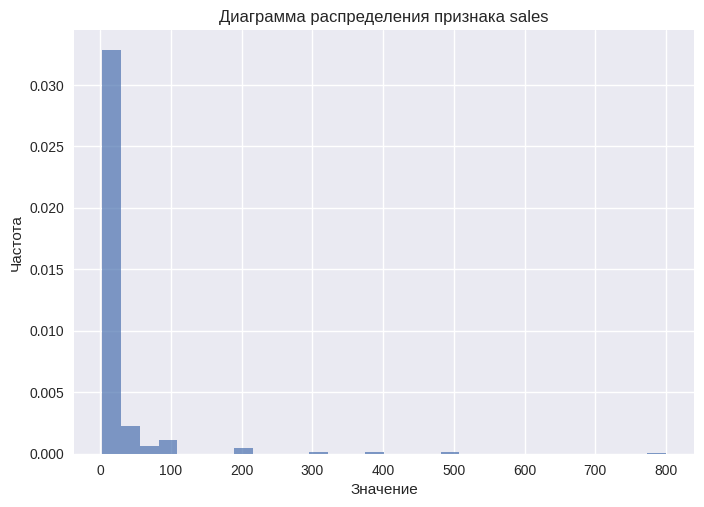

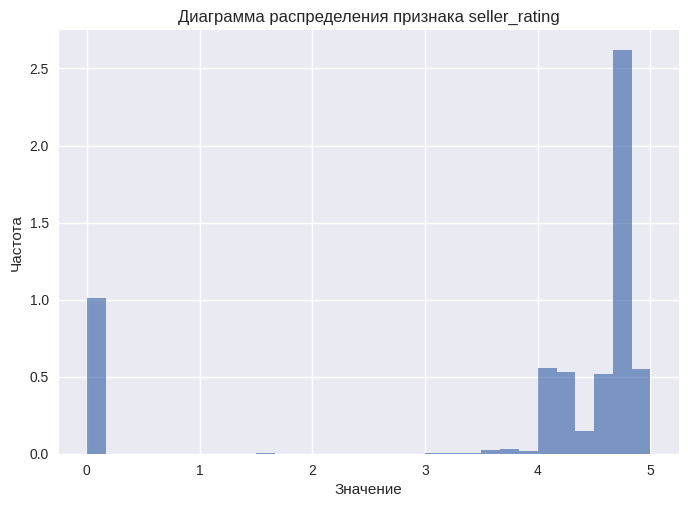

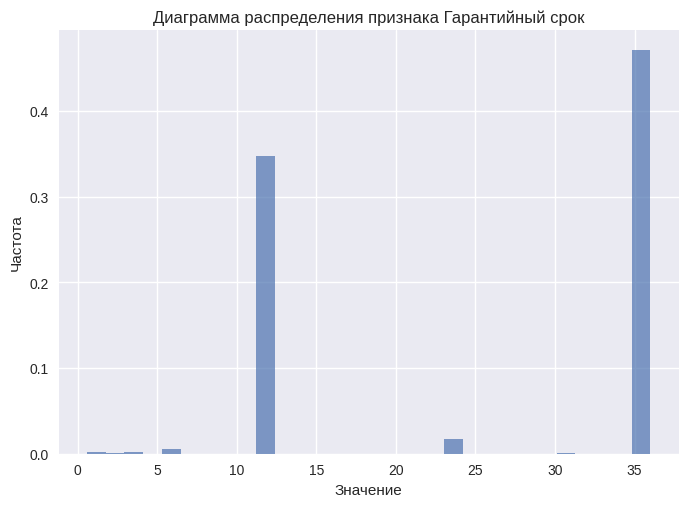

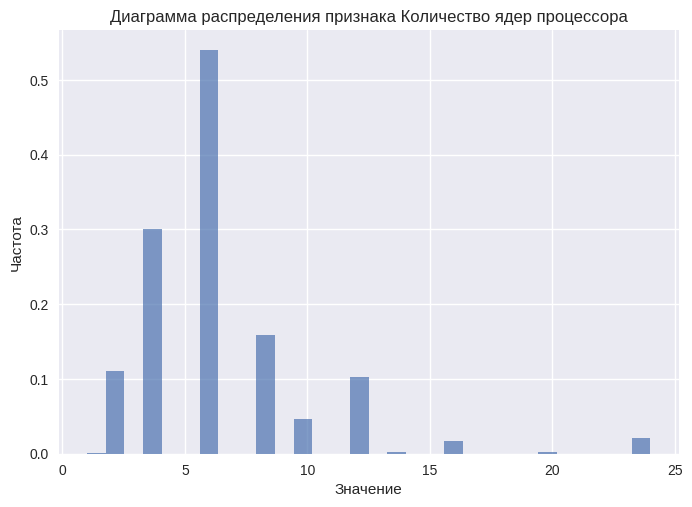

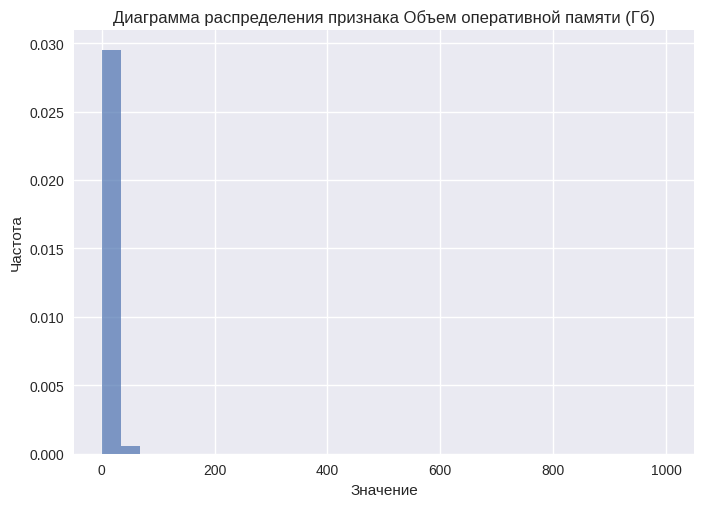

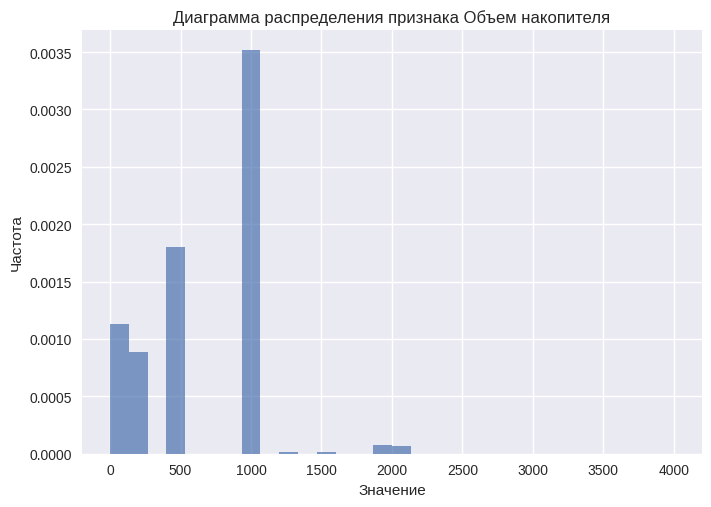

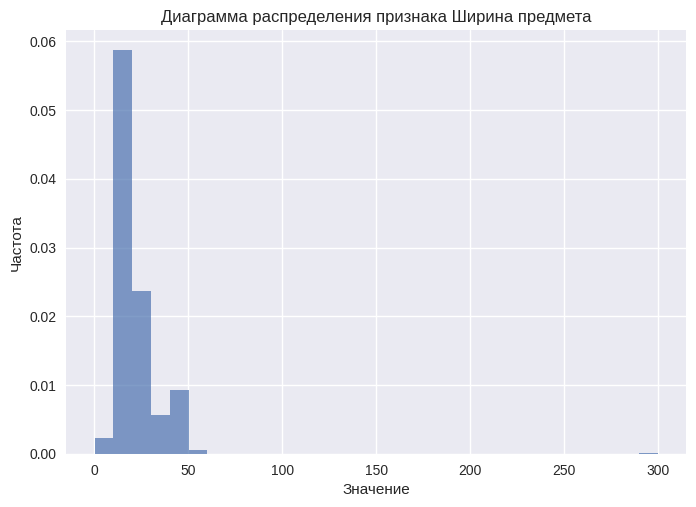

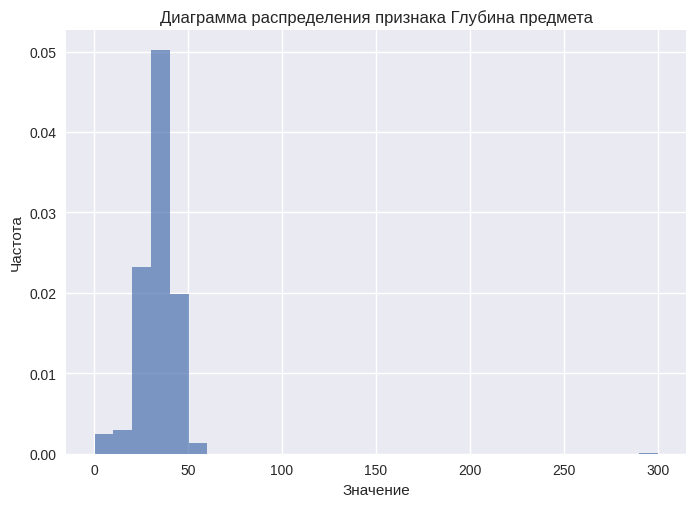

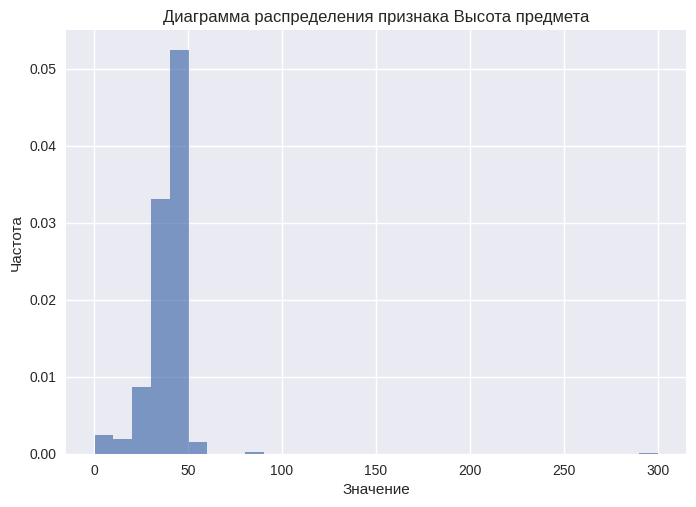

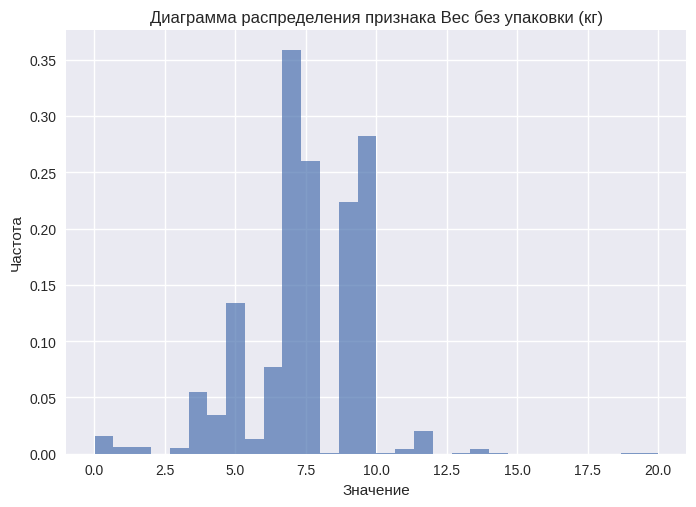

In [ ]:
for i, column in enumerate(numeric_columns_with_missing_values):
  plt.hist(df_copy[column], bins=30, density=True, alpha=0.7, label="Histogram")
  plt.title(f'Диаграмма распределения признака {column}')
  plt.xlabel('Значение')
  plt.ylabel('Частота')
  plt.show()

На графиках мы видим как правоскошенные, так и левоскошенные данные. Пропуски в них лучше заполнить медианной, потому что среднее значение в таком роаспределениии будет сильно зависить от экстремальных значений, а медиана будет находится в центре всего распределения. Данные распределением близким к нормальному также можно заполнить медианой, потому что в таких случаях среднее и медина не сильно отличаются.

#### Пропуски в категориальных переменных

Посмотрим, в каких категоральных переменных есть пропуски

In [ ]:
categorical_features = [col for col in df_copy.select_dtypes(include=['object']).columns]
categorical_features

['title',
 'seller',
 'Процессор',
 'Оперативная память',
 'Жесткий диск',
 'Видеопроцессор',
 'Операционная система',
 'Страна производства',
 'Габариты товара',
 'Габариты товара (с упаковкой)',
 'Тип процессора',
 'Тип оперативной памяти',
 'Тип накопителя',
 'Версия операционной системы',
 'Пробная операционная система',
 'Версия процессора',
 'Версия видеопроцессора']

Будем кодировать категориальные переменные с помощью OneHotEncoder, так как данные переменные не имеют иерархию, и обычная замена на 0, 1, 2 и дт. приведет к неверной интрепретации моделью значений в данных признаках (одни значения воспринимались бы лучше других). OneHotEncoder же создает отдельные столбцы для каждого значения.

### Выбросы

Посмотрим на выбросы в датасете в числовых признаках.

In [ ]:
numerical_features = ['sales', 'feedbacks', 'seller_rating', 'Гарантийный срок', 'Количество ядер процессора',
 'Объем оперативной памяти (Гб)', 'Объем накопителя', 'Ширина предмета', 'Глубина предмета', 'Высота предмета', 'Вес без упаковки (кг)']

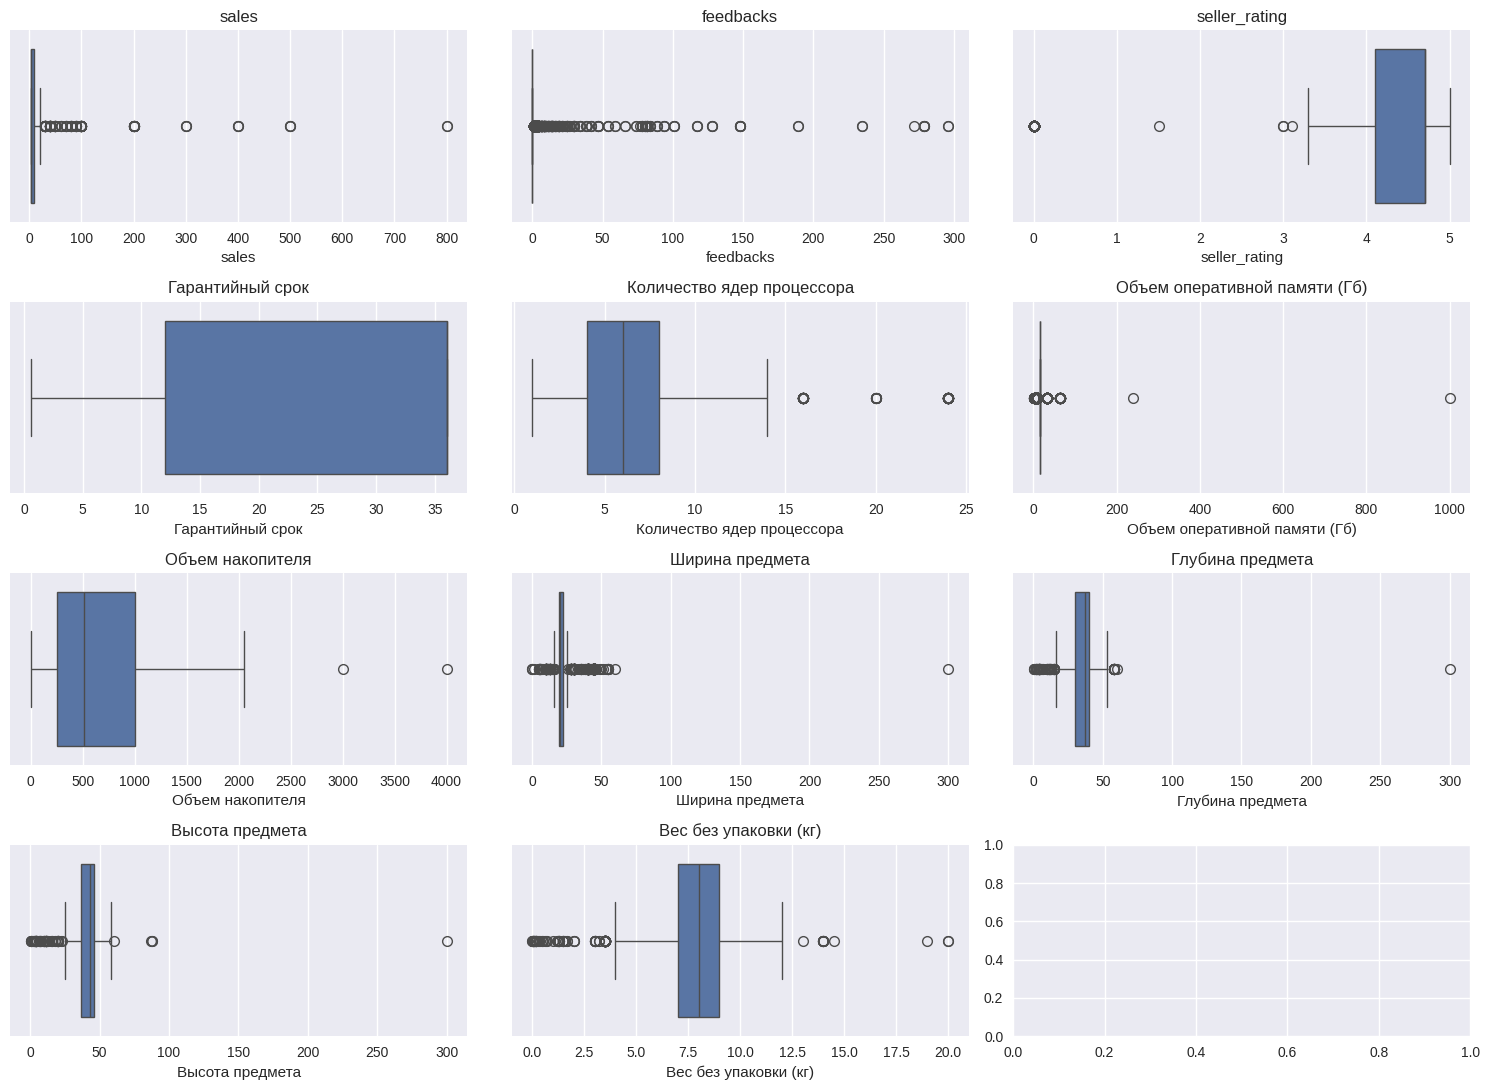

In [ ]:
fig, axes = plt.subplots(len(numerical_features)//3 + 1, 3, figsize=(15, len(numerical_features)))
axes = axes.flatten()

for idx, feature in enumerate(numerical_features):
    sns.boxplot(x=df_copy[feature], ax=axes[idx])
    axes[idx].set_title(feature)

plt.tight_layout()
plt.show()

In [ ]:
df_copy.to_csv('pc_analysis.csv') # Сохраним обработанный датасет

## Анализ взаимосвязей отдельных колонок и их визуализация

Сначала посмотрим, как цена товара зависит от остальных признаков, что будет полезно при дальнейщем обучении модели.

In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4080 entries, 0 to 4499
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_id                     4080 non-null   float64
 1   title                          4080 non-null   object 
 2   price                          4080 non-null   float64
 3   sales                          1059 non-null   float64
 4   feedbacks                      4080 non-null   float64
 5   seller                         3983 non-null   object 
 6   seller_rating                  3982 non-null   float64
 7   Процессор                      4080 non-null   object 
 8   Оперативная память             4080 non-null   object 
 9   Жесткий диск                   4080 non-null   object 
 10  Видеопроцессор                 4080 non-null   object 
 11  Операционная система           3480 non-null   object 
 12  Гарантийный срок               2410 non-null   float6

Необходимо посмотреть, как цена и популярность зависят от комплектующих. Среди них Количественные: количество ядер процессора, объём оперативной памяти, объём накопителя.  
Категориальные: видеопроцессор, операционная система, тип процессора, тип оперативной памяти, тип накопителя + созданные ранее столбцы (версия операционной системы, пробная операционная система, версия процессора, версия видеопроцессора).

### Цена

In [ ]:
# для большей наглядности отсортируем значения
df_sort_price = df_copy.sort_values(by='price', ascending=False)
df_sort_price

,product_id,title,price,sales,feedbacks,seller,seller_rating,Процессор,Оперативная память,Жесткий диск,...,Тип накопителя,Объем накопителя,Ширина предмета,Глубина предмета,Высота предмета,Вес без упаковки (кг),Версия операционной системы,Пробная операционная система,Версия процессора,Версия видеопроцессора
4053,151574147.0,"Игровой компьютер i7 13700KF, RTX 4070 Ti 12GB...",235900.0,NaN,0.0,KING KOMP,4.1,"{'Процессор_тип': 'Intel Core i7', 'Количество...","{'Тип оперативной памяти': 'DDR 5', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",...,SSD,1500.0,28.0,45.0,45.0,20.0,NaN,NaN,i7,geforce rtx 4070
4034,151567319.0,"Игровой компьютер AMD Ryzen 9 7900X, RTX 3080,...",215900.0,NaN,0.0,KING KOMP,4.1,"{'Процессор_тип': 'AMD Ryzen 9', 'Количество я...","{'Тип оперативной памяти': 'DDR 5', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",...,SSD,1000.0,50.0,50.0,50.0,20.0,NaN,NaN,ryzen 9,geforce rtx 3080
1241,114465982.0,Мощный игровой компьютер Зевс 2.0 V3,214954.0,20.0,9.0,Robotcomp,4.7,"{'Процессор_тип': 'Intel Core i9', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': '2000 Гб', 'Объем нак...",...,HDD,2000.0,23.0,47.0,44.0,8.0,10,Полная,i9,geforce rtx 3080
1242,114465983.0,Мощный игровой компьютер Зевс 2.0 V3,214954.0,5.0,9.0,Robotcomp,4.7,"{'Процессор_тип': 'Intel Core i9', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': '2000 Гб', 'Объем нак...",...,HDD,2000.0,23.0,47.0,44.0,8.0,10,Полная,i9,geforce rtx 3080
1240,114461367.0,Мощный игровой компьютер Зевс 2.0 V2,209955.0,3.0,1.0,Robotcomp,4.7,"{'Процессор_тип': 'Intel Core i9', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': '2000 Гб', 'Объем нак...",...,HDD,2000.0,23.0,47.0,44.0,8.0,10,Полная,i9,geforce rtx 3080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171,46732522.0,LAN кабель для интернета cat5e RJ45 1Гбит/ па...,150.0,100.0,82.0,Flash-ca,4.6,"{'Процессор_тип': 'не заполнено', 'Количество ...","{'Тип оперативной памяти': 'не заполнено', 'Об...","{'Объем накопителя HDD': None, 'Объем накопите...",...,None,0.0,NaN,NaN,NaN,NaN,10 pro,Полная,не заполнено,не заполнено
170,46732473.0,LAN кабель для интернета cat5e RJ45 1Гбит/ па...,150.0,100.0,82.0,Flash-ca,4.6,"{'Процессор_тип': 'не заполнено', 'Количество ...","{'Тип оперативной памяти': 'не заполнено', 'Об...","{'Объем накопителя HDD': None, 'Объем накопите...",...,None,0.0,NaN,NaN,NaN,NaN,10 pro,Полная,не заполнено,не заполнено
125,44855374.0,Патч корд - сетевой кабель для интернета,143.0,10.0,14.0,Flash-ca,4.6,"{'Процессор_тип': 'не заполнено', 'Количество ...","{'Тип оперативной памяти': 'не заполнено', 'Об...","{'Объем накопителя HDD': None, 'Объем накопите...",...,None,0.0,NaN,NaN,NaN,NaN,10,Полная,не заполнено,не заполнено
168,46730596.0,LAN кабель для интернета cat5e RJ45 1Гбит/ па...,140.0,200.0,82.0,Flash-ca,4.6,"{'Процессор_тип': 'не заполнено', 'Количество ...","{'Тип оперативной памяти': 'не заполнено', 'Об...","{'Объем накопителя HDD': None, 'Объем накопите...",...,None,0.0,NaN,NaN,NaN,NaN,10 pro,Полная,не заполнено,не заполнено


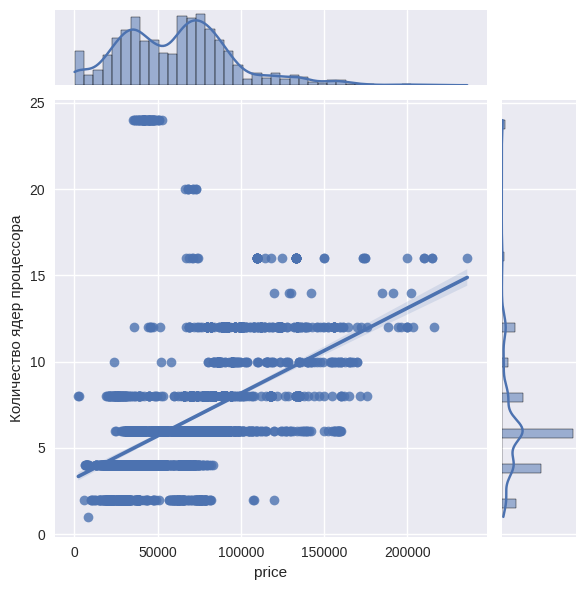

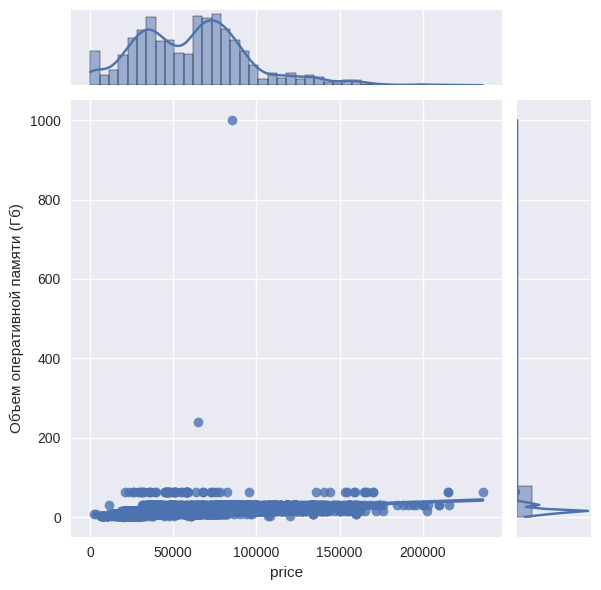

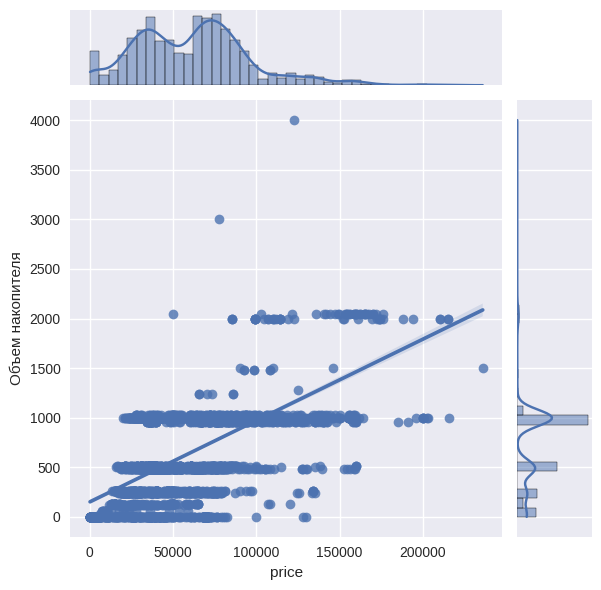

In [ ]:
# Зависимость цены от количественных признаков
num_columns = ['Количество ядер процессора', 'Объем оперативной памяти (Гб)', 'Объем накопителя']
for i in num_columns:
  sns.jointplot(x = 'price', y = str(i), data=df_sort_price, kind="reg")

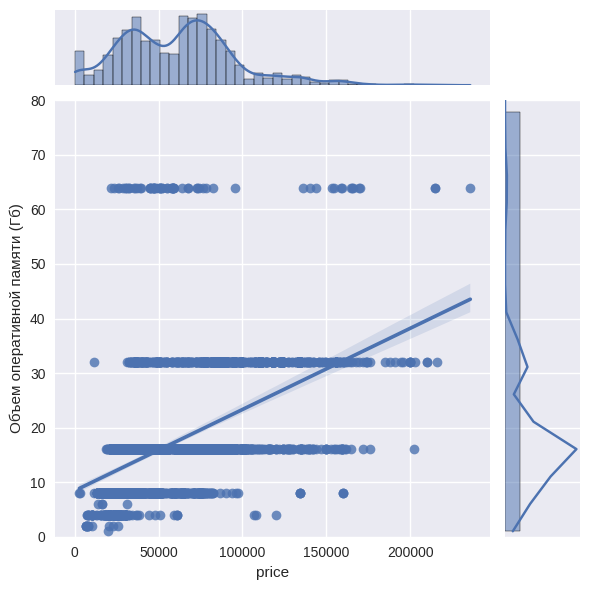

In [ ]:
# Отдельно посмотрим оперативную память
sns.jointplot(x = 'price', y = 'Объем оперативной памяти (Гб)', data=df_sort_price, kind="reg", ylim=(0, 80))

Можно заметить прямую зависимость цены от комплектующих

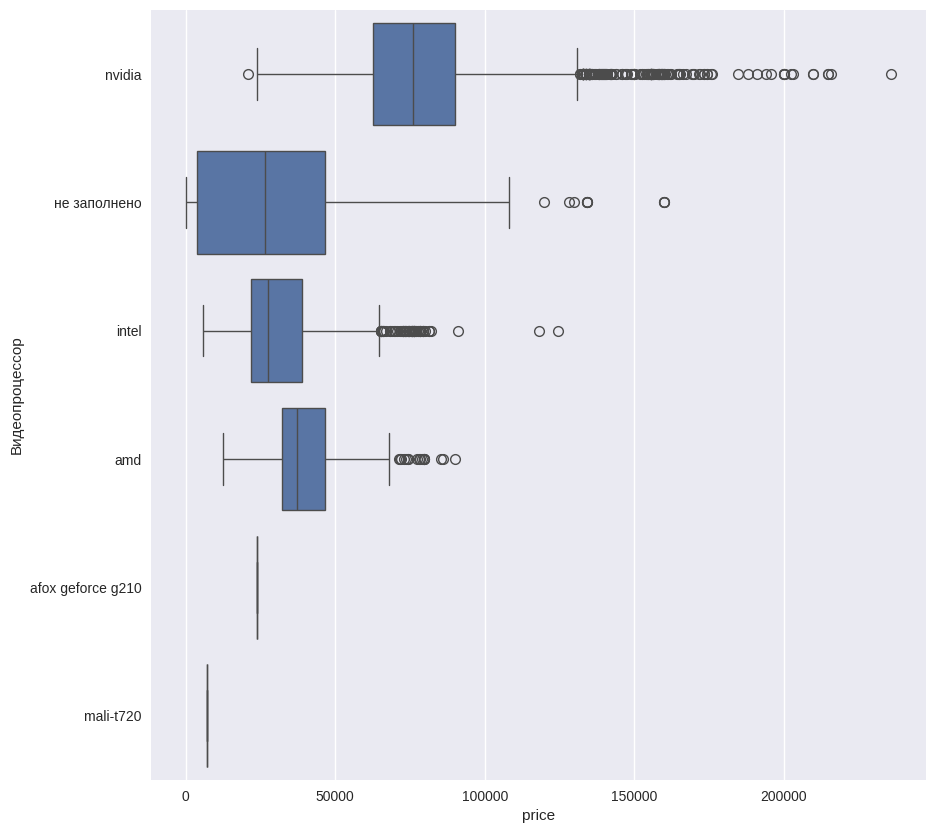

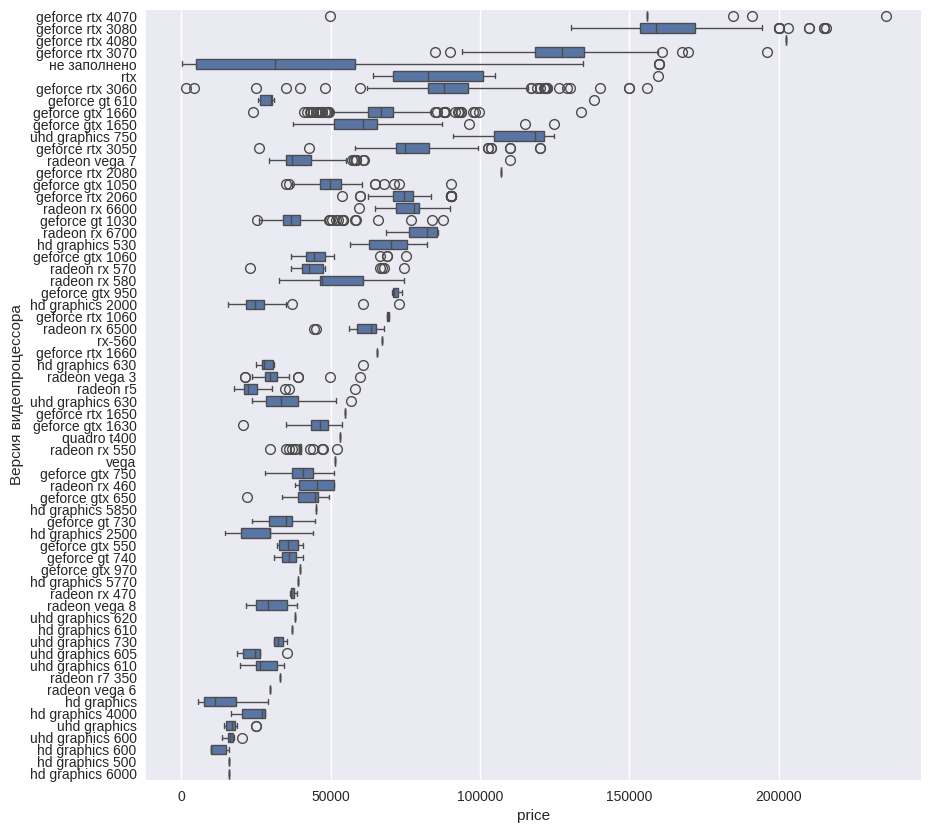

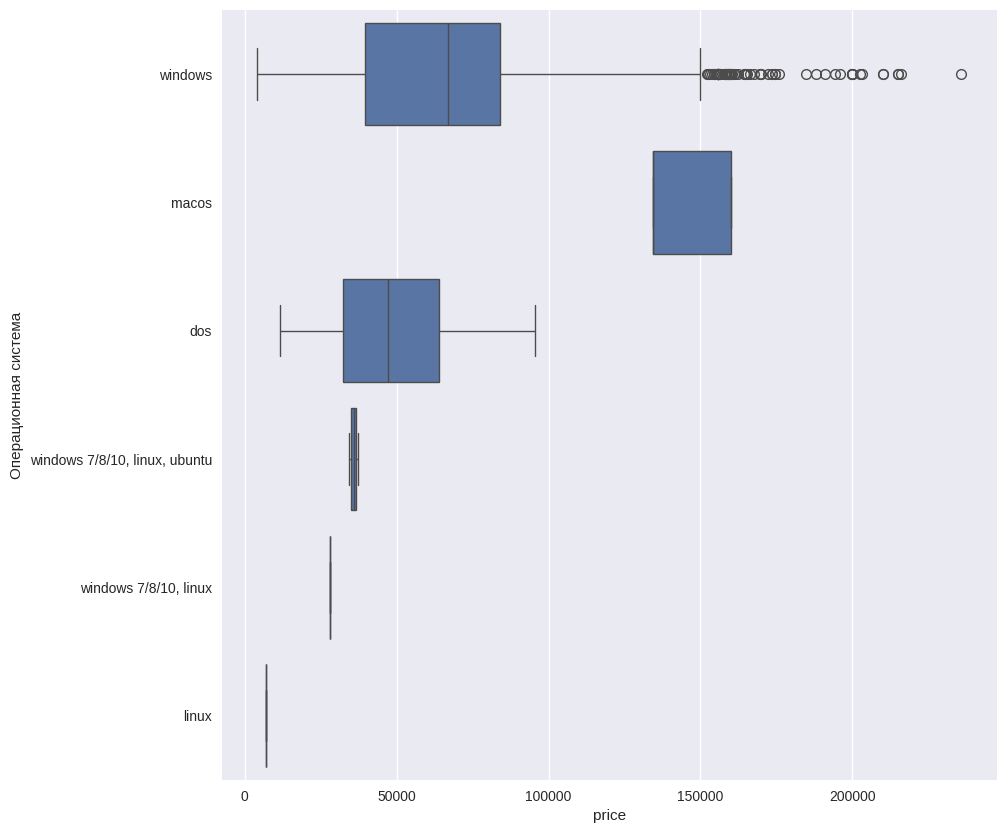

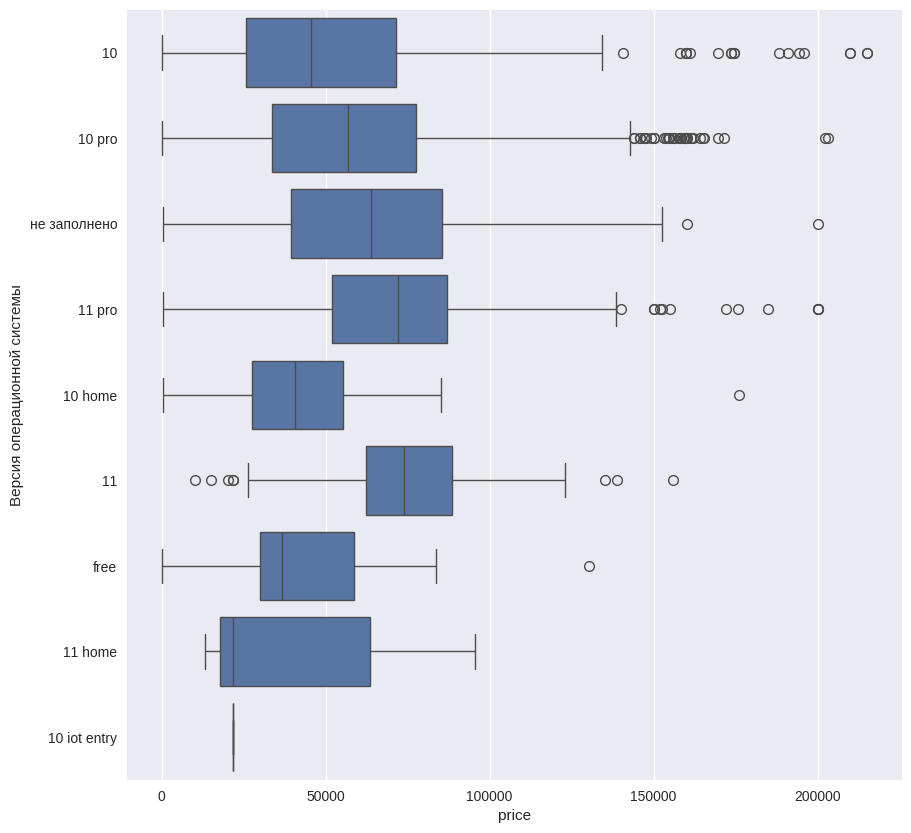

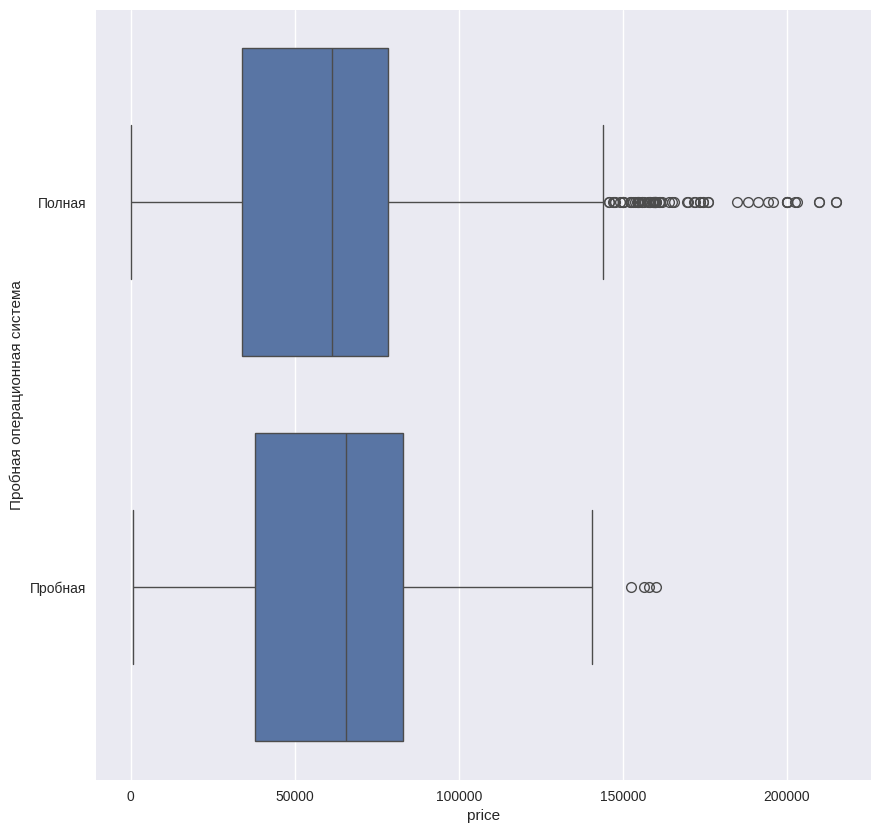

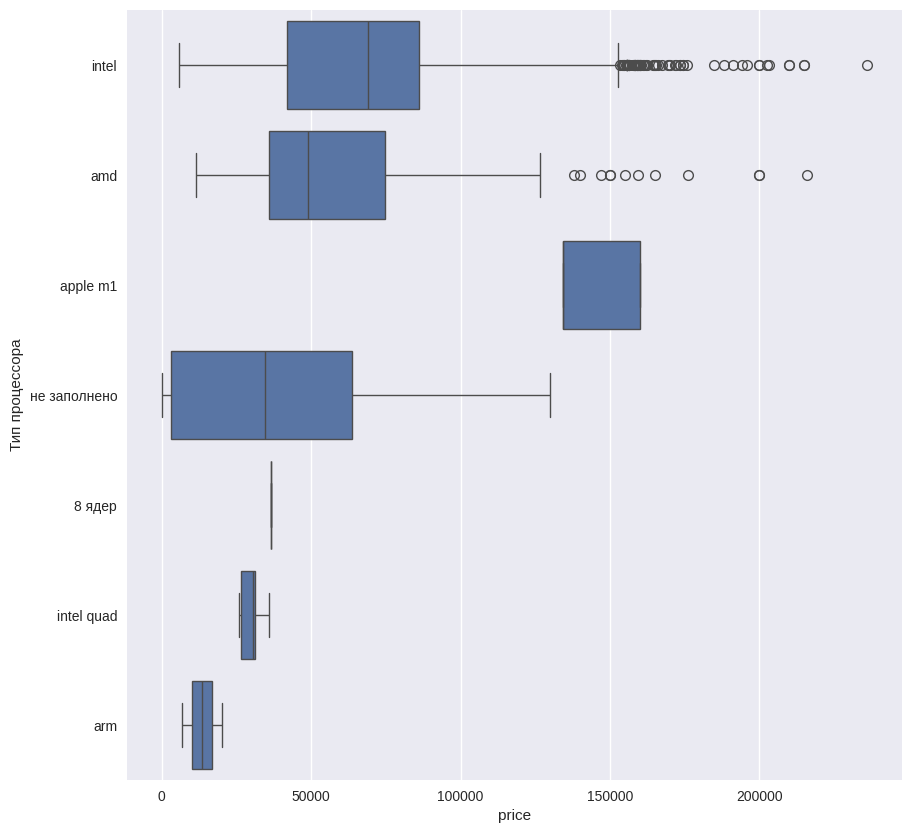

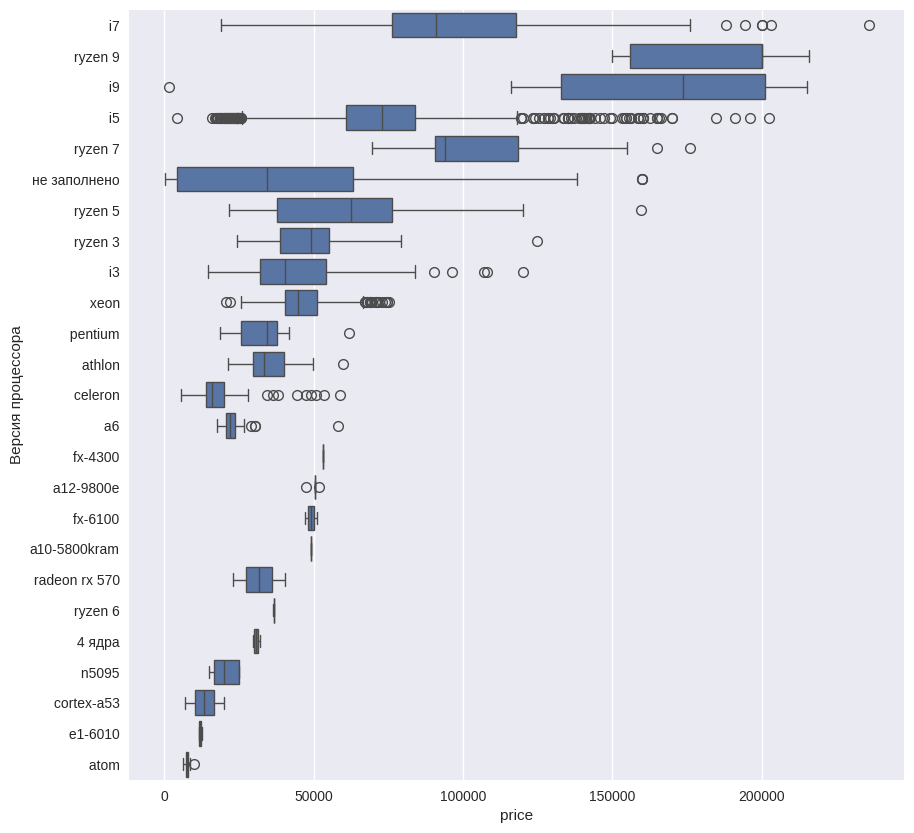

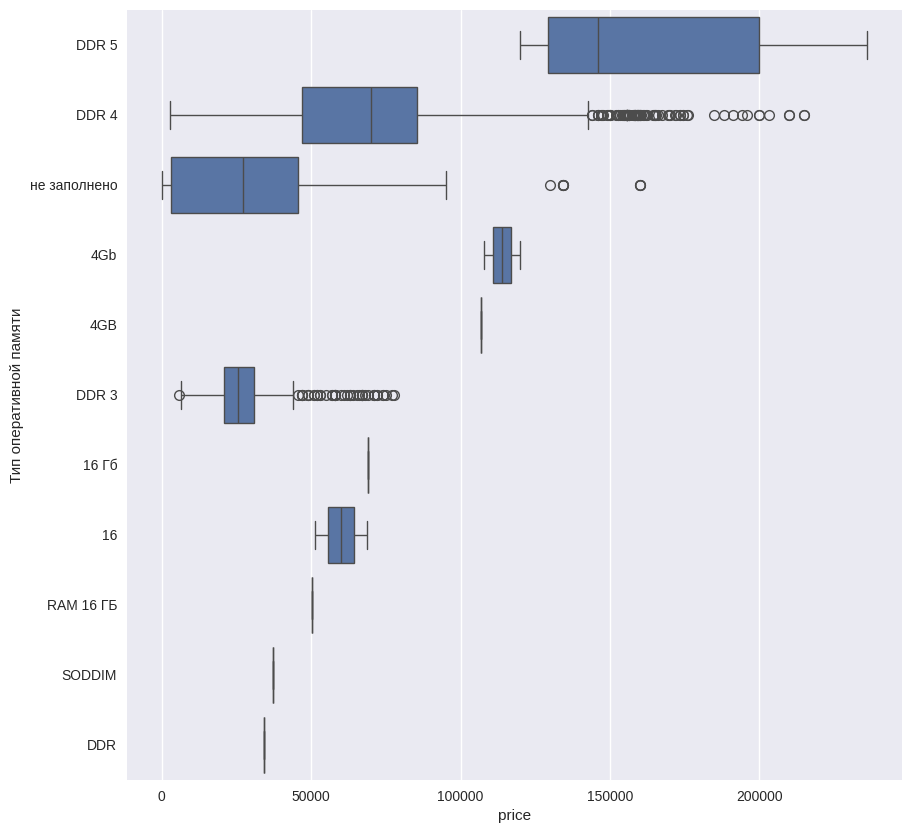

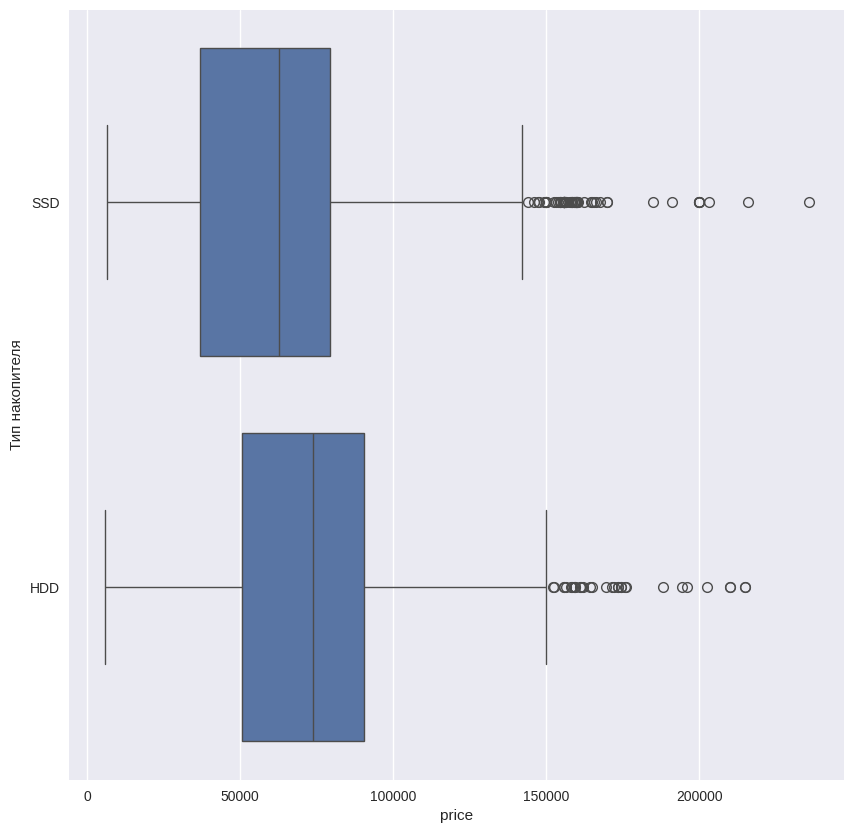

In [ ]:
# Для категориальных признаков
str_columns = ['Видеопроцессор', 'Версия видеопроцессора', 'Операционная система', 'Версия операционной системы', 'Пробная операционная система',  'Тип процессора', 'Версия процессора', 'Тип оперативной памяти', 'Тип накопителя']
for i in str_columns:
  f, ax = plt.subplots(figsize=(10, 10))
  fig = sns.boxplot(x='price', y=str(i), data=df_sort_price)

Наиболее дорогие комплектующие: видеопроцессор NVIDIA GeForce RTX 3080, операционная система macOS (интересно, что операционные системы с пробным периодом более дорогие), тип процессора apple, но самый дорогой процессор в выборке - AMD Ryzen 9, тип оперативной памяти DDR 5, тип накопителя HDD.

### Популярность

In [ ]:
df_sort_sales = df_copy.sort_values(by='sales', ascending=False)
df_sort_sales

,product_id,title,price,sales,feedbacks,seller,seller_rating,Процессор,Оперативная память,Жесткий диск,...,Тип накопителя,Объем накопителя,Ширина предмета,Глубина предмета,Высота предмета,Вес без упаковки (кг),Версия операционной системы,Пробная операционная система,Версия процессора,Версия видеопроцессора
1918,142153356.0,Игровой компьютер i7-2600 16Gb SSD 512Gb GT 73...,32900.0,800.0,80.0,ALFA-SYSTEM,4.8,"{'Процессор_тип': 'Intel Core i7', 'Количество...","{'Тип оперативной памяти': 'DDR 3', 'Объем опе...","{'Объем накопителя HDD': 'нет', 'Объем накопит...",...,HDD,NaN,NaN,NaN,NaN,4.0,10 pro,Полная,i7,geforce gt 730
113,43240828.0,Компьютер Raskat (Intel Pentium G6400/4Gb/120G...,36990.0,800.0,3.0,NaN,NaN,"{'Процессор_тип': 'Intel Pentium', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",...,SSD,120.0,17.8,17.8,3.4,2.0,10 pro,Полная,pentium,hd graphics 610
74,25968600.0,Игровой Компьютер Robotcomp Старт V1,30760.0,500.0,148.0,Robotcomp,4.7,"{'Процессор_тип': 'Intel Core i3', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",...,SSD,480.0,20.0,42.0,46.0,7.0,10 pro,Полная,i3,geforce gt 1030
1870,140001995.0,Системный блок ПК i5-2400 8 Гб SSD 256 Гб,20400.0,500.0,279.0,ALFA-SYSTEM,4.8,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 3', 'Объем опе...","{'Объем накопителя HDD': 'нет', 'Объем накопит...",...,HDD,NaN,NaN,NaN,NaN,5.0,10 pro,Полная,i5,hd graphics
28,20904019.0,Игровой Компьютер Robotcomp Аллигатор V3,34017.0,500.0,128.0,Robotcomp,4.7,"{'Процессор_тип': 'AMD Ryzen 5', 'Количество я...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",...,SSD,480.0,20.0,40.0,45.0,7.0,10 pro,Полная,ryzen 5,radeon vega 7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4495,152971271.0,Игровой ПК,70000.0,NaN,0.0,Personal PC,0.0,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': '1000 гб', 'Объем нак...",...,HDD,1000.0,35.0,40.0,50.0,9.0,NaN,NaN,i5,не заполнено
4496,152978335.0,Игровой ПК,70000.0,NaN,0.0,Personal PC,0.0,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': '1000 Гб', 'Объем нак...",...,HDD,1000.0,35.0,40.0,50.0,9.0,NaN,NaN,i5,не заполнено
4497,152979371.0,Игровой ПК,70000.0,NaN,0.0,Personal PC,0.0,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': '1000 Гб', 'Объем нак...",...,HDD,1000.0,35.0,40.0,50.0,9.0,NaN,NaN,i5,не заполнено
4498,152979918.0,Игровой ПК,70000.0,NaN,0.0,Personal PC,0.0,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': '1000 гб', 'Объем нак...",...,HDD,1000.0,30.0,40.0,50.0,9.0,NaN,NaN,i5,не заполнено


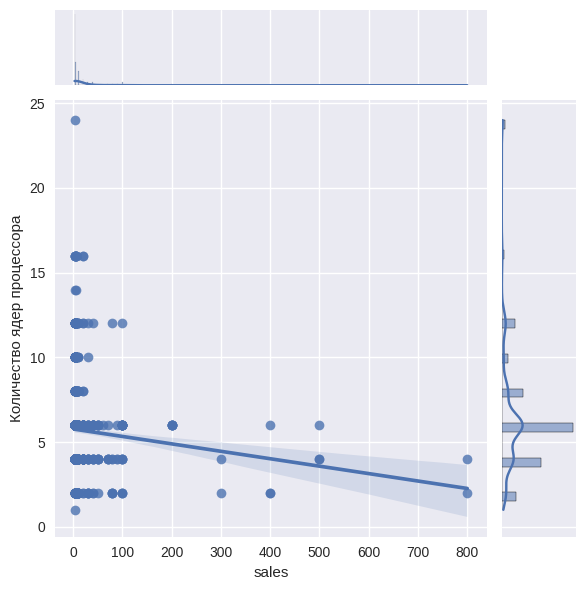

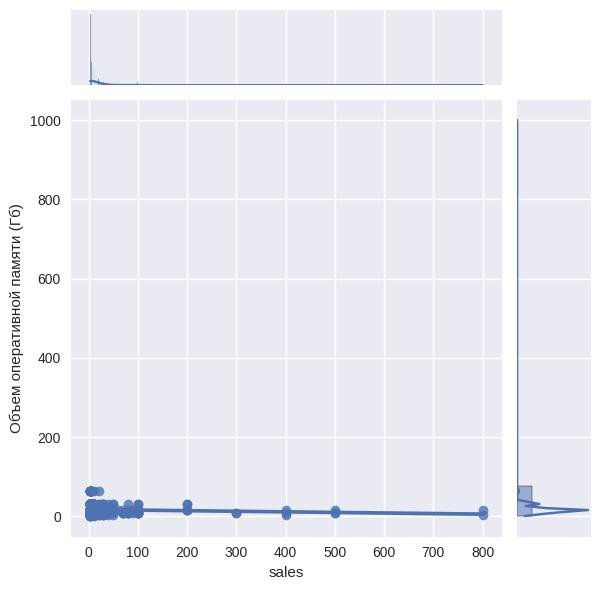

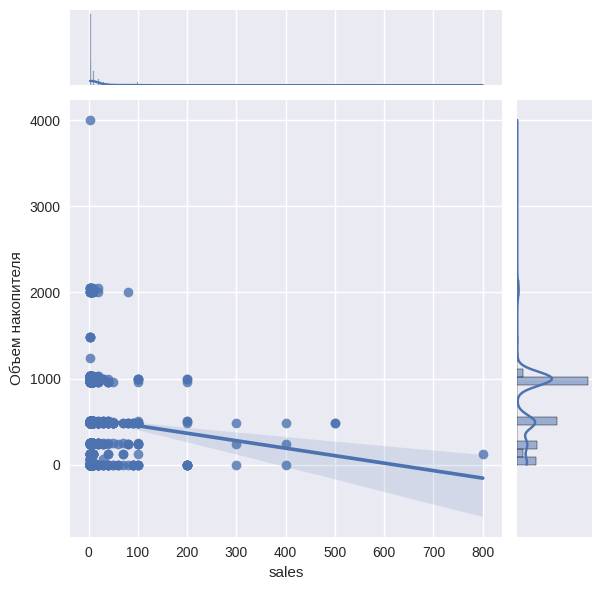

In [ ]:
for i in num_columns:
  sns.jointplot(x = 'sales', y = i, data=df_sort_sales, kind="reg")

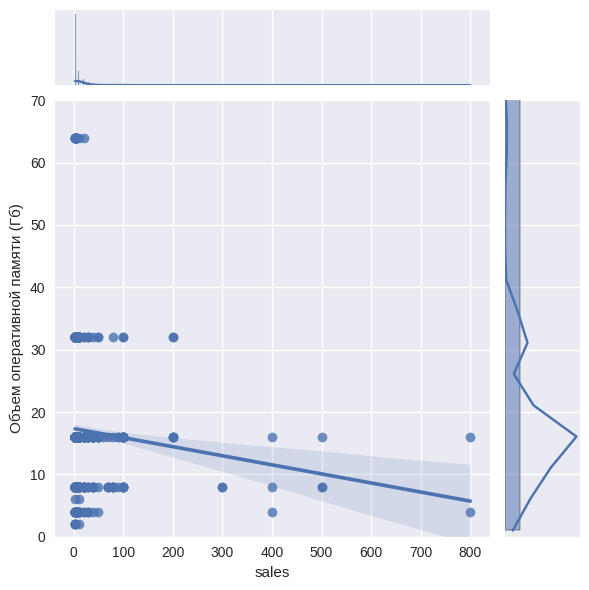

In [ ]:
sns.jointplot(x = 'sales', y = 'Объем оперативной памяти (Гб)', data=df_sort_sales, kind="reg", ylim=(0, 70))

Можно заметить, что с улучшением характеристик компьютера популярность падает. Это может быть связано с повышением их стоимости.

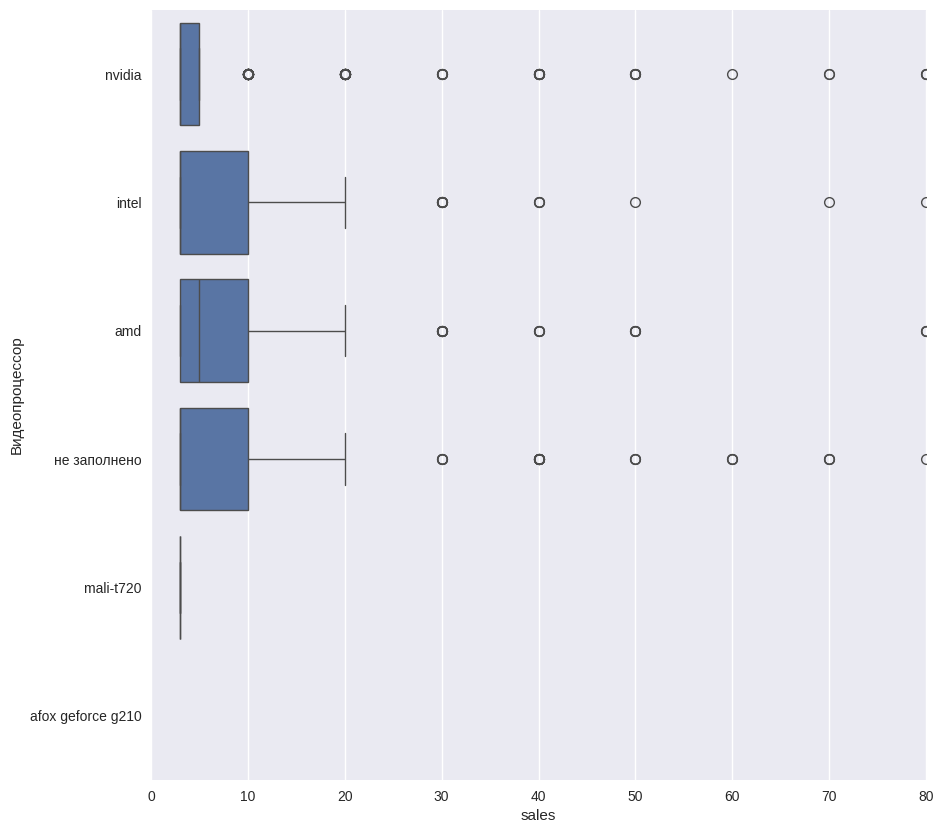

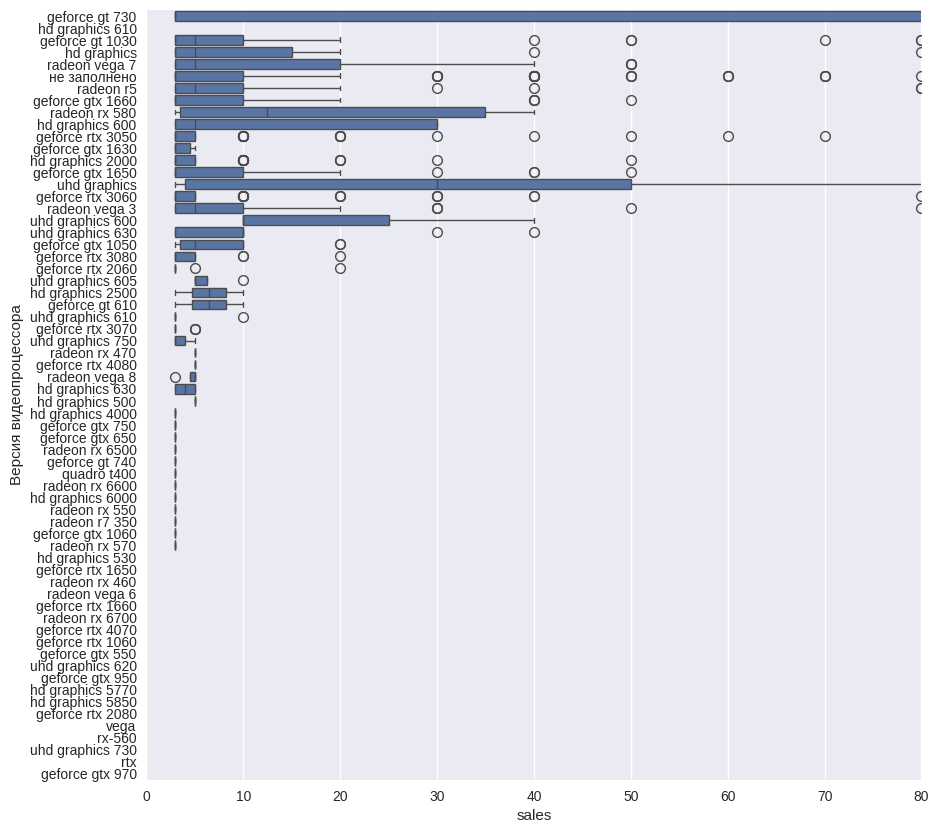

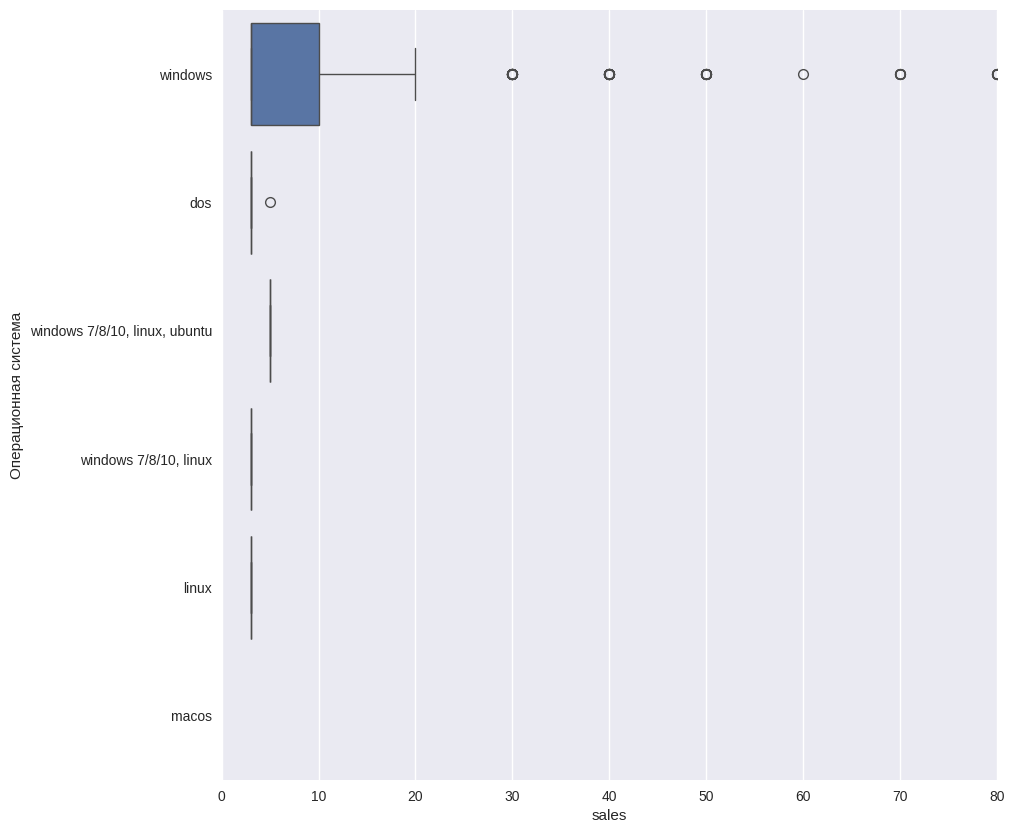

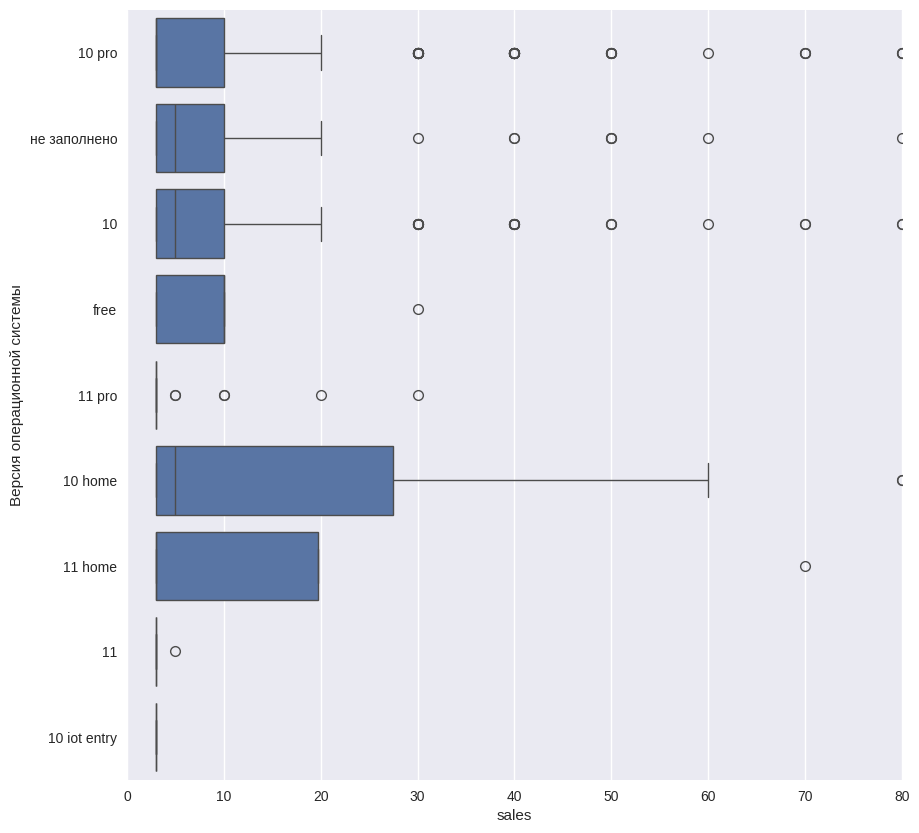

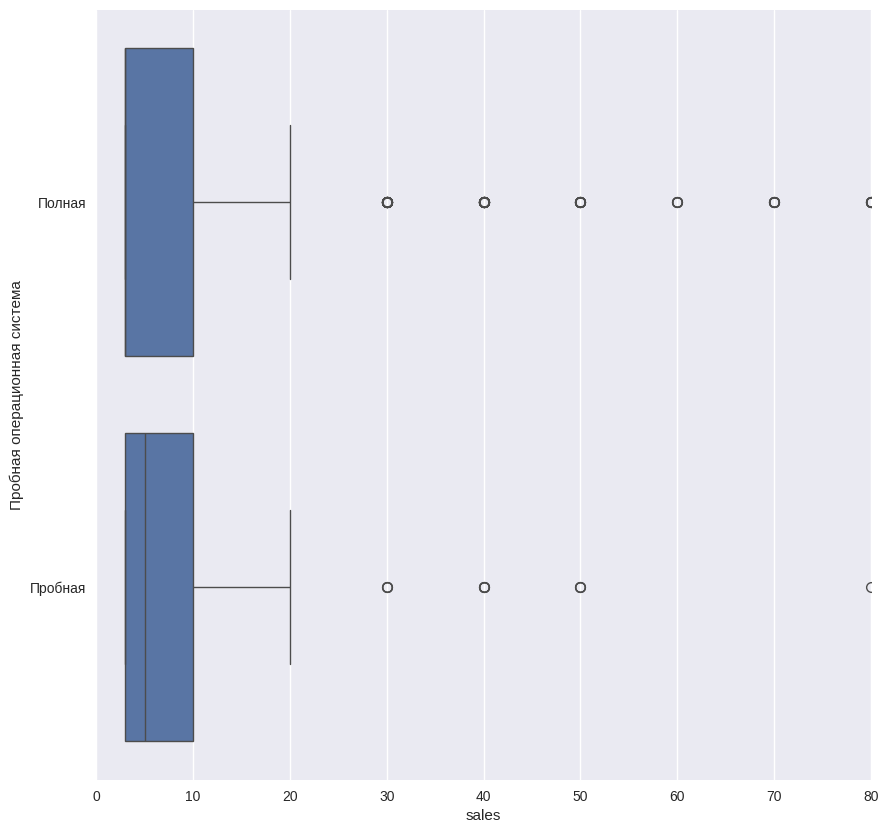

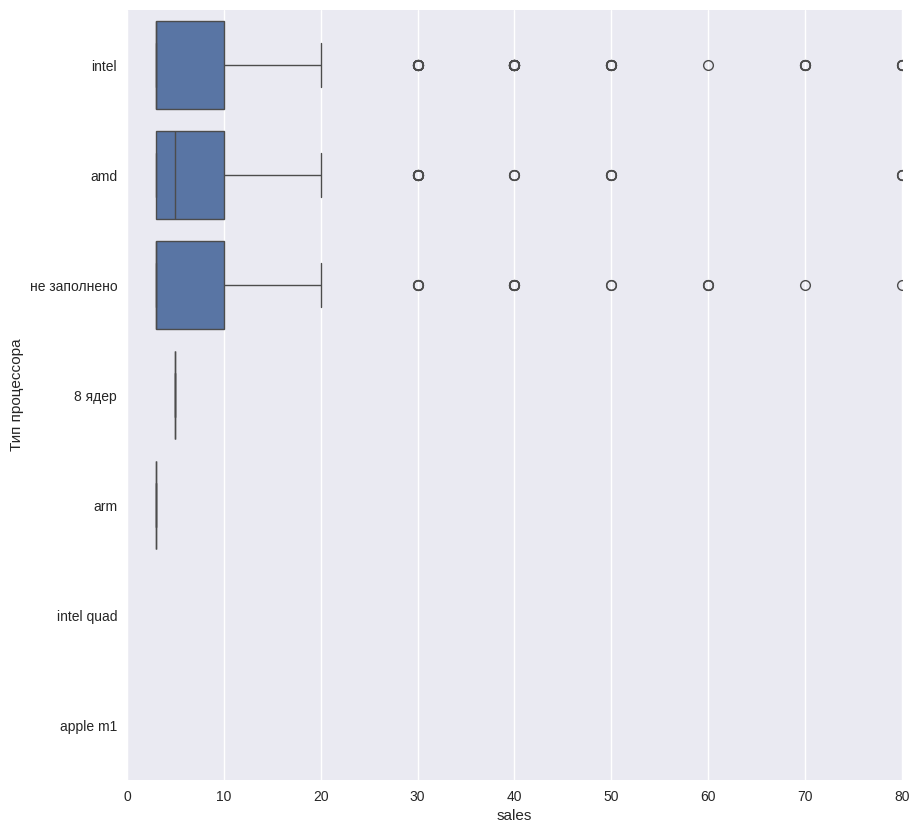

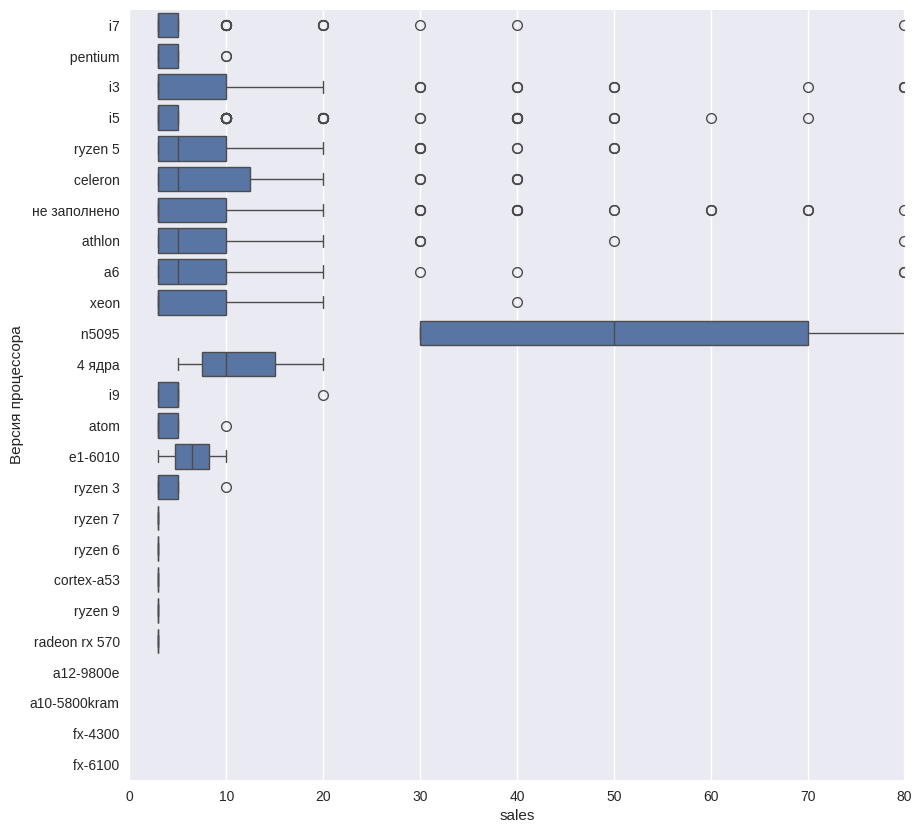

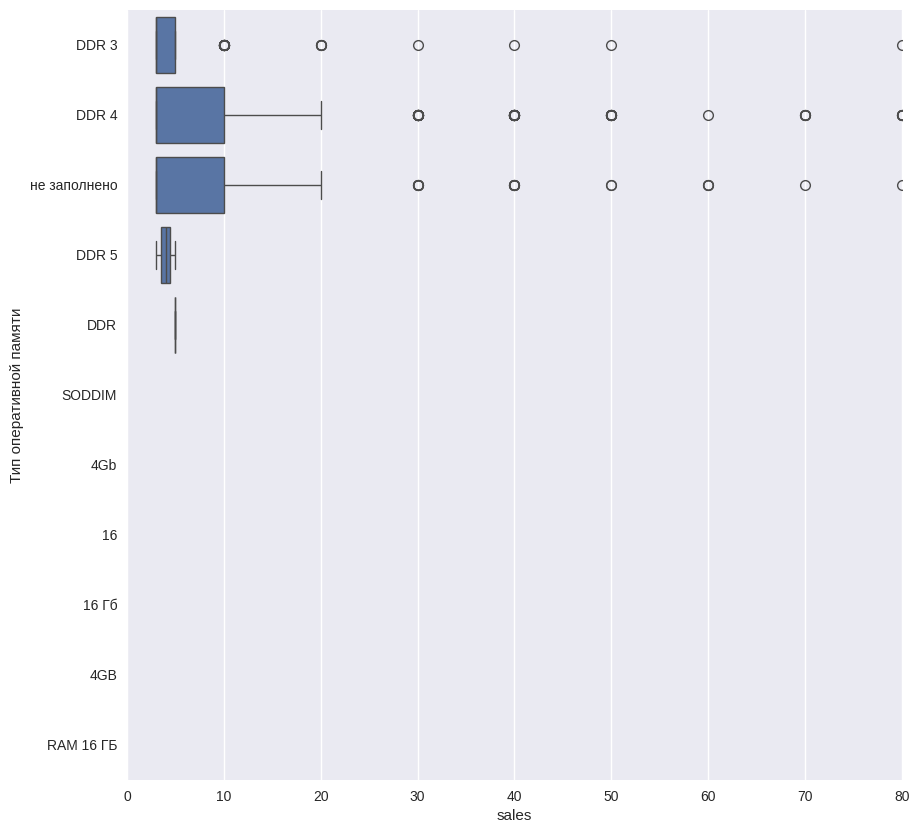

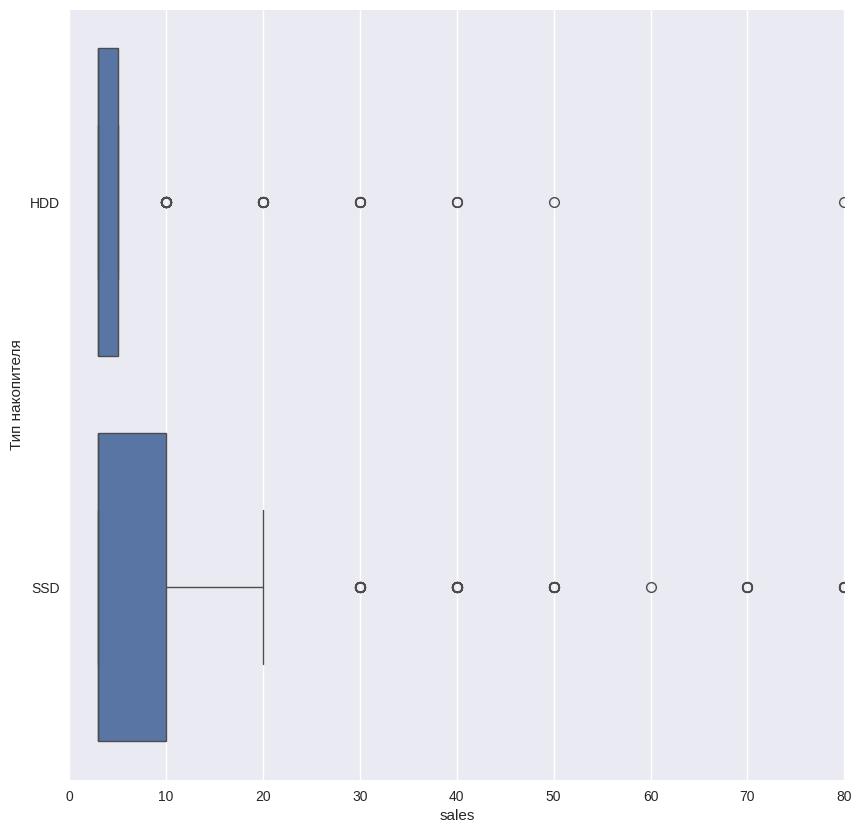

In [ ]:
# Для категориальных признаков
for i in str_columns:
  f, ax = plt.subplots(figsize=(10, 10))
  fig = sns.boxplot(x='sales', y=i, data=df_sort_sales)
  fig.set_xlim(0, 80)

Наиболее популярные комплектующие: видеопроцессоры intel и amd, но из версий самая популярная - NVIDIA GeForce 730, Windows 10 Home (пробные и полные версии распределены примерно одинаково), Intel N5095, DDR 4, SSD. Эти комплектующие находятся в достаточно низком ценовом диапазоне.

## Вывод

1. Удалено 418 дубликотов
2. Решено заполнить пропученные значение в числовых признаках медианой, а в категориальных - значением "не заполнено"
3. Удалено одно пропущенное значение в целеной переменной "price"
4. Найдены признаки с выбросами, которые нужно обработать
5. Проанализированна взаимосвязь цены и популярности ПК от его комплектуащих
6. Получен датасет с 4080 наблюдениями.

# Модель регрессии

## Разбиение данных

In [ ]:
from sklearn.model_selection import train_test_split

pc_train_val, pc_test = train_test_split(df_copy, test_size=0.15, random_state=25)
pc_train, pc_val = train_test_split(pc_train_val, test_size=0.176, random_state=25)

In [ ]:
print(pc_train.shape)
print(pc_val.shape)
print(pc_test.shape)

(2857, 30)
(611, 30)
(612, 30)


In [ ]:
X_train = pc_train.drop(columns=['price'])
y_train = pc_train['price']
X_test = pc_test.drop(columns=['price'])
y_test = pc_test['price']
X_val = pc_val.drop(columns=['price'])
y_val = pc_val['price']

Сразу создадим копию X_train, чтобы проверить работу трансформеров.

In [ ]:
X_train_copy = X_train.copy()

## Трансформеры

### Удаление ненужных признаков

In [ ]:
drop_features  = ['title', 'product_id', 'Габариты товара (с упаковкой)']

In [ ]:
from feature_engine.selection import DropFeatures

tr_drop = DropFeatures(features_to_drop=drop_features)
# X_train = tr_drop.fit_transform(X_train)
# X_test = tr_drop.transform(X_test)

In [ ]:
X_train_copy = tr_drop.fit_transform(X_train_copy)

Проверим, что признаки были удалены.

In [ ]:
X_train_copy.head(2)

,sales,feedbacks,seller,seller_rating,Процессор,Оперативная память,Жесткий диск,Видеопроцессор,Операционная система,Гарантийный срок,...,Тип накопителя,Объем накопителя,Ширина предмета,Глубина предмета,Высота предмета,Вес без упаковки (кг),Версия операционной системы,Пробная операционная система,Версия процессора,Версия видеопроцессора
1690,10.0,4.0,D-Tora,4.1,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 3', 'Объем опе...","{'Объем накопителя HDD': '500 Gb', 'Объем нако...",intel,windows,12.0,...,HDD,500.0,19.5,32.6,39.8,6.5,10 pro,Полная,i5,hd graphics 2000
1597,NaN,0.0,Континент,4.5,"{'Процессор_тип': 'AMD Athlon', 'Количество яд...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",amd,windows,36.0,...,SSD,240.0,NaN,NaN,NaN,NaN,10 pro,Полная,athlon,radeon vega 3


### Обработка пропусков

In [ ]:
from feature_engine.imputation import MeanMedianImputer

imputer_median = MeanMedianImputer(imputation_method='median', variables=['sales', 'seller_rating', 'Гарантийный срок', 'Количество ядер процессора', 'Объем оперативной памяти (Гб)', 'Объем накопителя', 'Ширина предмета', 'Глубина предмета', 'Высота предмета', 'Вес без упаковки (кг)'])

In [ ]:
X_train_copy = imputer_median.fit_transform(X_train_copy)

Заполним категориальные переменные с пропусками занчением "не заполнено", которое есть в других признаках датасета.

In [ ]:
from feature_engine.imputation import CategoricalImputer

imputer_categorical = CategoricalImputer(variables=['seller', 'Страна производства', 'Тип накопителя', 'Операционная система', 'Версия операционной системы', 'Пробная операционная система', 'Версия процессора'], fill_value="не заполнено")

In [ ]:
X_train_copy = imputer_categorical.fit_transform(X_train_copy)

Посмотрим, что все пропуски заполнены.

In [ ]:
X_train_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2857 entries, 1690 to 3822
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   sales                          2857 non-null   float64
 1   feedbacks                      2857 non-null   float64
 2   seller                         2857 non-null   object 
 3   seller_rating                  2857 non-null   float64
 4   Процессор                      2857 non-null   object 
 5   Оперативная память             2857 non-null   object 
 6   Жесткий диск                   2857 non-null   object 
 7   Видеопроцессор                 2857 non-null   object 
 8   Операционная система           2857 non-null   object 
 9   Гарантийный срок               2857 non-null   float64
 10  Страна производства            2857 non-null   object 
 11  Габариты товара                2857 non-null   object 
 12  Тип процессора                 2857 non-null   obj

### Кодирование категориальных переменных

Кодируем категориальные переменные с помощью OneHotEncoder.

In [ ]:
categorical_features = [col for col in X_train_copy.select_dtypes(include=['object']).columns]
categorical_features

['seller',
 'Процессор',
 'Оперативная память',
 'Жесткий диск',
 'Видеопроцессор',
 'Операционная система',
 'Страна производства',
 'Габариты товара',
 'Тип процессора',
 'Тип оперативной памяти',
 'Тип накопителя',
 'Версия операционной системы',
 'Пробная операционная система',
 'Версия процессора',
 'Версия видеопроцессора']

In [ ]:
import category_encoders as ce
from sklearn.preprocessing import OneHotEncoder

encoder = ce.OneHotEncoder(cols=categorical_features, drop_invariant=True, use_cat_names=True)
# X_train = encoder.fit_transform(X_train)
# X_test = encoder.transform(X_test)

In [ ]:
X_train_copy = encoder.fit_transform(X_train_copy)

Посмотрим, что данные были закодированы.

In [ ]:
X_train_copy.head()

,sales,feedbacks,seller_D-Tora,seller_Континент,seller_Buchok,seller_M-Bit,seller_Robotcomp,seller_Roo24.ru,seller_SHARK,seller_I-GAMEZ КОМПЬЮТЕРЫ,...,Версия видеопроцессора_uhd graphics 620,Версия видеопроцессора_geforce rtx 1060,Версия видеопроцессора_vega,Версия видеопроцессора_radeon vega 6,Версия видеопроцессора_rx-560,Версия видеопроцессора_geforce rtx 1650,Версия видеопроцессора_radeon r7 350,Версия видеопроцессора_hd graphics 500,Версия видеопроцессора_hd graphics 5770,Версия видеопроцессора_geforce gt 740
1690,10.0,4.0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1597,3.0,0.0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
813,3.0,0.0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2698,3.0,0.0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4192,3.0,0.0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Обработка выбросов

Посмотрим на выбросы в датасете в числовых признаках.

In [ ]:
numerical_features = ['sales', 'feedbacks', 'seller_rating', 'Гарантийный срок', 'Количество ядер процессора',
 'Объем оперативной памяти (Гб)', 'Объем накопителя', 'Ширина предмета', 'Глубина предмета', 'Высота предмета', 'Вес без упаковки (кг)']

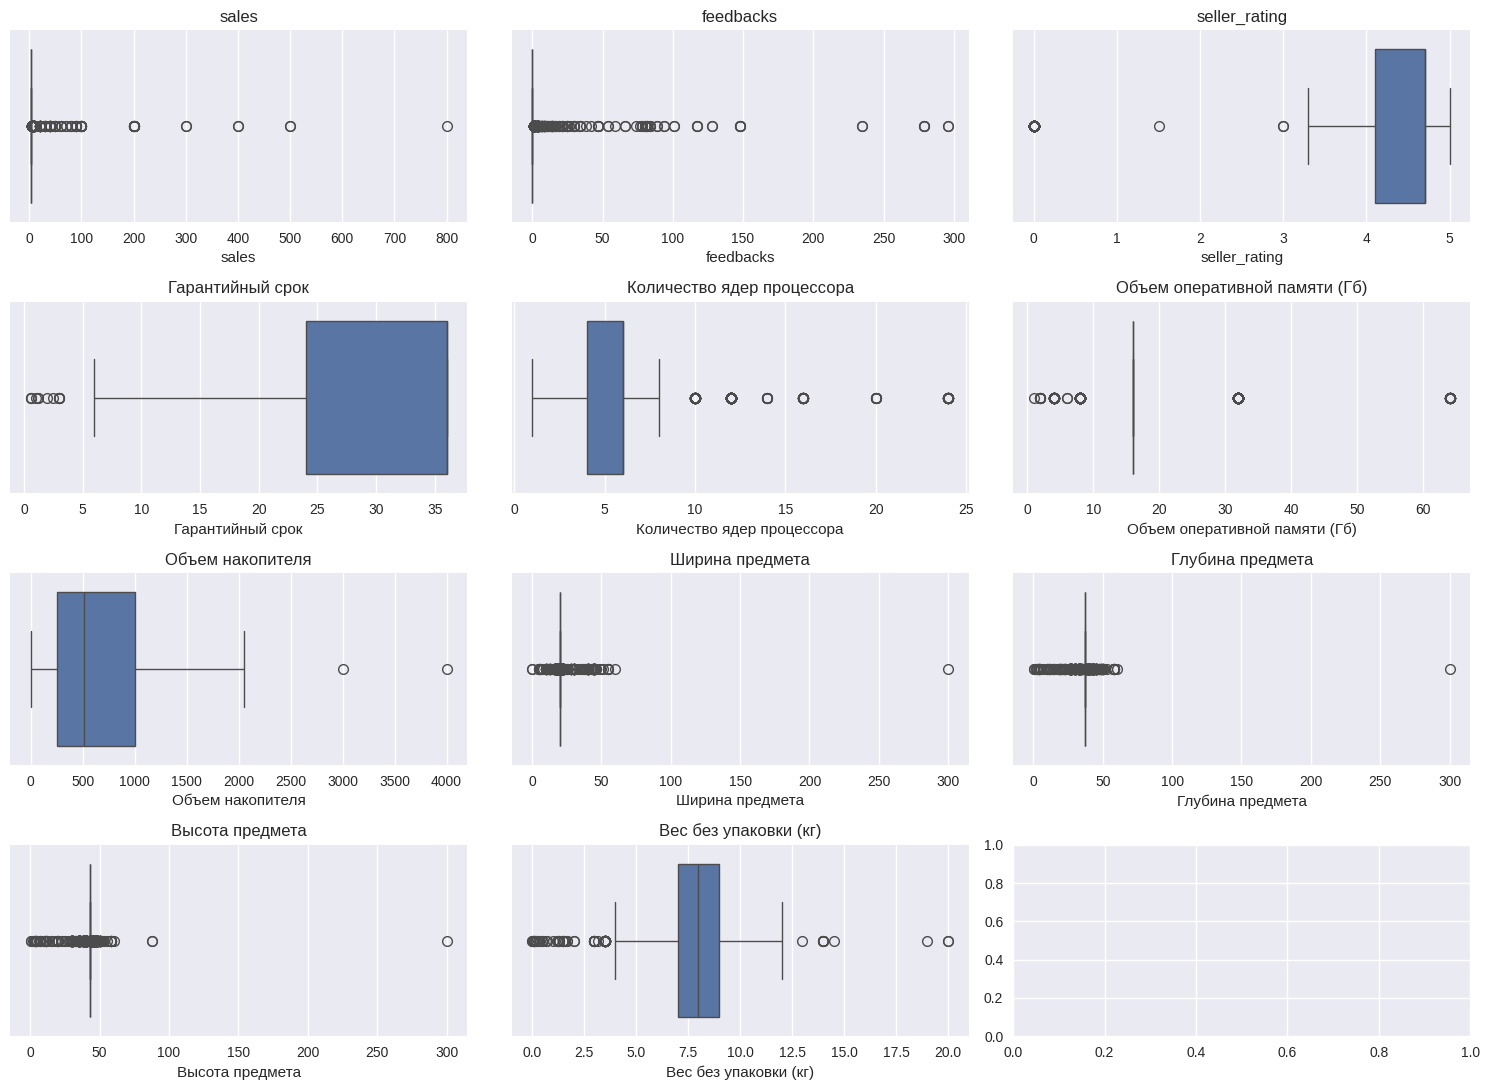

In [ ]:
fig, axes = plt.subplots(len(numerical_features)//3 + 1, 3, figsize=(15, len(numerical_features)))
axes = axes.flatten()

for idx, feature in enumerate(numerical_features):
    sns.boxplot(x=X_train_copy[feature], ax=axes[idx])
    axes[idx].set_title(feature)

plt.tight_layout()
plt.show()

In [ ]:
from feature_engine.outliers import Winsorizer

In [ ]:
tr_outliers = Winsorizer(
    tail="both",
    fold=1.5,  # по умолчанию в классе стоит граница - межквартильный размах, поэтому граница для выброса определяется как IQR * 1.5
    variables=numerical_features,
)

In [ ]:
X_train_copy = tr_outliers.fit_transform(X_train_copy)

Посмотрим, как изменилось распределение.

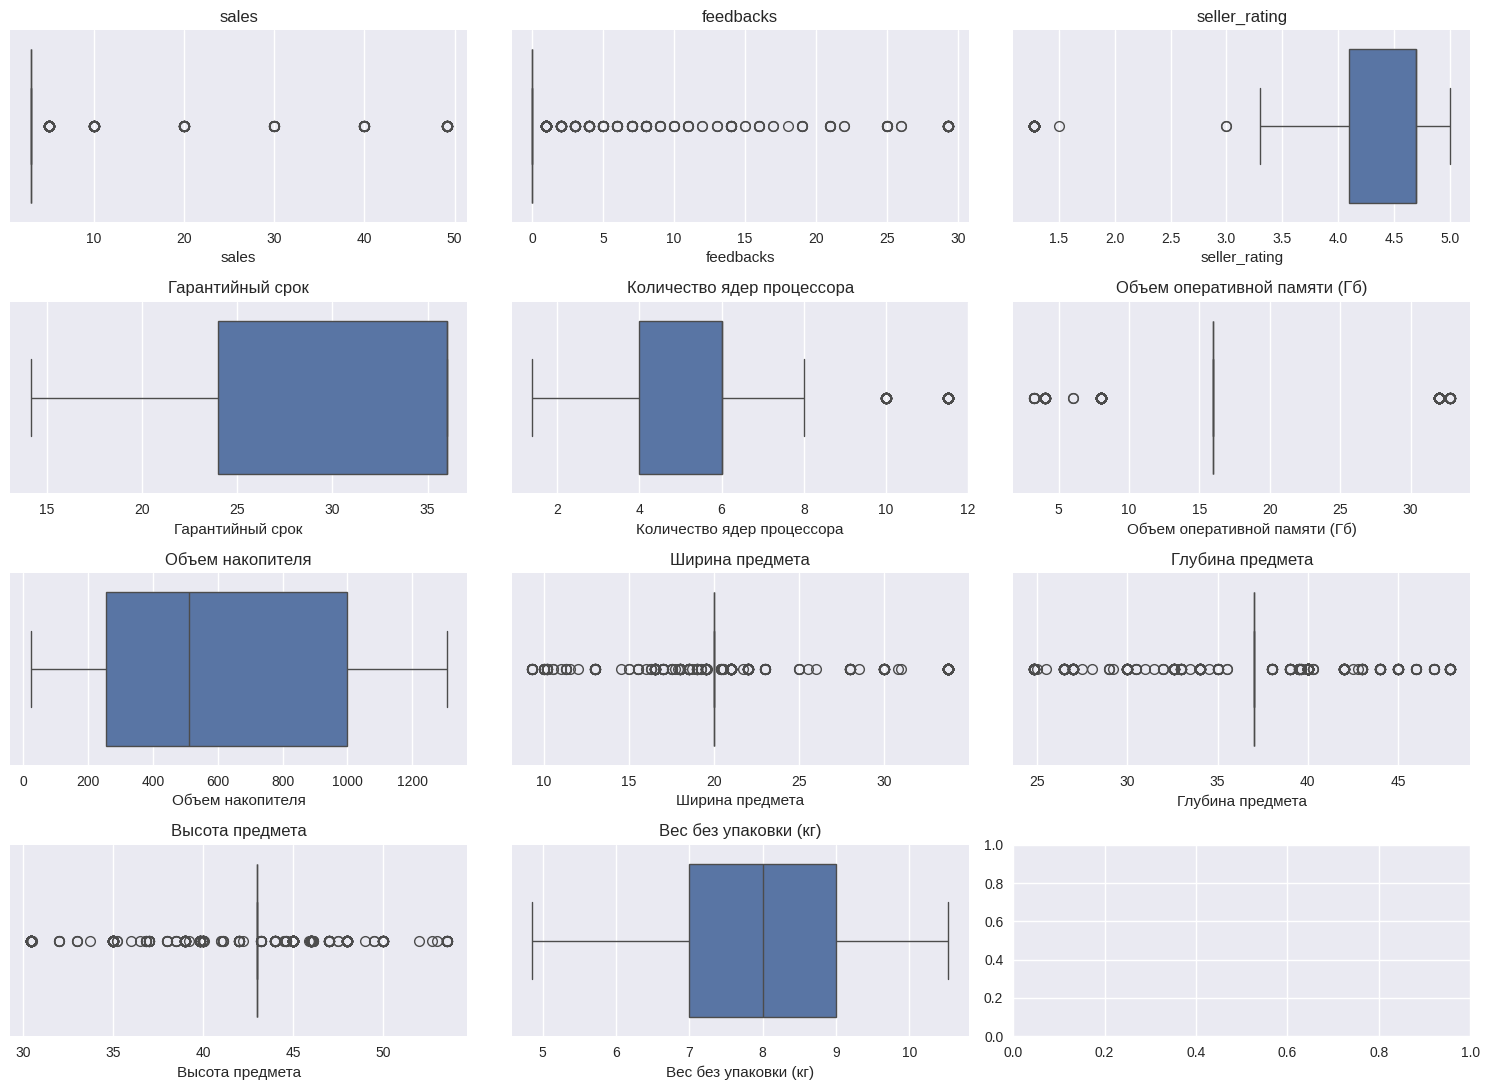

In [ ]:
fig, axes = plt.subplots(len(numerical_features)//3 + 1, 3, figsize=(15, len(numerical_features)))
axes = axes.flatten()

for idx, feature in enumerate(numerical_features):
    sns.boxplot(x=X_train_copy[feature], ax=axes[idx])
    axes[idx].set_title(feature)

plt.tight_layout()
plt.show()

### Выбор признаков

Выбор признаков является необходимым этапом, поскольку в процессе кодирования категориальных переменных было создано большое количество признаков, часть из которых может быть избыточной или неинформативной. Удаление таких признаков, а также устранение сильно коррелированных между собой переменных, способствует снижению размерности и уменьшению риска переобучения модели. Для этого применим специальные трансформеры, которые автоматически выявляют и исключают «ненужные» признаки на основе различных критериев.

Построим матрицу корреляций

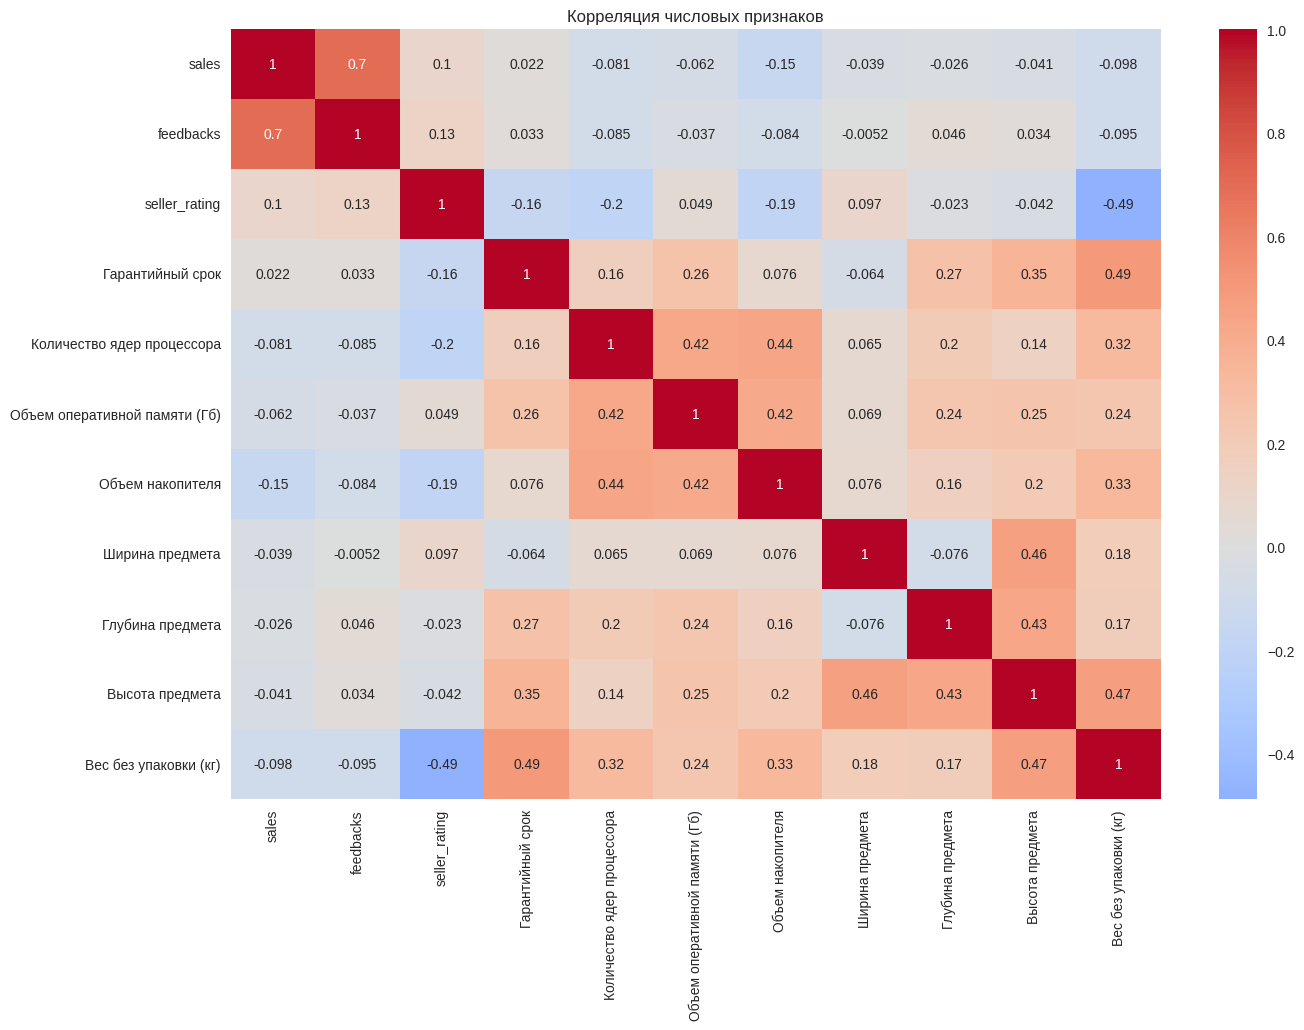

In [ ]:
corr_matrix = X_train_copy[numerical_features].corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Корреляция числовых признаков")
plt.show()

Нет ни одного признака с весьма высокой корреляцией.

Тперь применим трансформеры выбора признаков.

In [ ]:
from feature_engine.selection import (
    DropCorrelatedFeatures, SmartCorrelatedSelection, DropHighPSIFeatures, ProbeFeatureSelection
)
from sklearn.model_selection import cross_val_score

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

Оценим модель до применения трансформеров.

In [ ]:
model = LinearRegression()
model.fit(X_train_copy, y_train)
y_pred = model.predict(X_train_copy)
score = r2_score(y_train, y_pred)
print("R2 score на тренировочных данных:", score)

R2 score на тренировочных данных: 0.9744316140856112


Затем будем добавлять трансфомеры в модель и смотреть, уменьшилась или возросла метрика r^2.

In [ ]:
# Удаление сильно коррелированных признаков (порог 0.9 по умолчанию)
corr_features = DropCorrelatedFeatures()
X_train_corr = corr_features.fit_transform(X_train_copy)
print(f"Удаляем признаки: {corr_features.features_to_drop_}")

Удаляем признаки: ["Процессор_{'Процессор_тип': 'Intel J1800 2,0 GHz quad core', 'Количество ядер процессора': 'не заполнено'}", "Жесткий диск_{'Объем накопителя HDD': '500; 500 гб', 'Объем накопителя SSD': '128; 128 гб'}", "Оперативная память_{'Тип оперативной памяти': 'DDR 4', 'Объем оперативной памяти (Гб)': '16ГБ'}", "Жесткий диск_{'Объем накопителя HDD': '1000 Гб', 'Объем накопителя SSD': '480 ГБ'}", "Процессор_{'Процессор_тип': 'Intel Celeron', 'Количество ядер процессора': '4 ядра'}", 'Версия видеопроцессора_hd graphics 2000', "Габариты товара_{'Ширина предмета': '11 см', 'Глубина предмета': '4.3 см', 'Высота предмета': '10 см', 'Вес без упаковки (кг)': '0.5 кг'}", "Жесткий диск_{'Объем накопителя HDD': None, 'Объем накопителя SSD': '256 Gb'}", "Оперативная память_{'Тип оперативной памяти': 'не заполнено', 'Объем оперативной памяти (Гб)': '8 GB'}", "Габариты товара_{'Ширина предмета': '20 см', 'Глубина предмета': '40 см', 'Высота предмета': '40 см', 'Вес без упаковки (кг)': '7 к

In [ ]:
model = LinearRegression()
model.fit(X_train_corr, y_train)
y_pred_corr = model.predict(X_train_corr)

r2 = r2_score(y_train, y_pred_corr)
print(f'R2 для X_train_corr: {r2}')

R2 для X_train_corr: 0.9743546045152709


In [ ]:
# Удаление коррелированных признаков с умным выбором (оставляет признак с наибольшей дисперсией)
cor_selector = SmartCorrelatedSelection(
    method="pearson",
    threshold=0.8,
    selection_method="variance")
X_train_smart = cor_selector.fit_transform(X_train_copy, y_train)
print(f"Удаляемые признаки: {cor_selector.features_to_drop_}")

Удаляемые признаки: ["Габариты товара_{'Ширина предмета': None, 'Глубина предмета': None, 'Высота предмета': None, 'Вес без упаковки (кг)': '10 кг'}", "Жесткий диск_{'Объем накопителя HDD': None, 'Объем накопителя SSD': '1000 Гб'}", 'seller_M-Bit', 'Страна производства_не заполнено', "Процессор_{'Процессор_тип': 'Intel Core i5', 'Количество ядер процессора': '6'}", 'Версия операционной системы_не заполнено', "Жесткий диск_{'Объем накопителя HDD': '1000 Гб', 'Объем накопителя SSD': '480 ГБ'}", 'Операционная система_не заполнено', 'Видеопроцессор_не заполнено', 'Тип накопителя_не заполнено', "Жесткий диск_{'Объем накопителя HDD': None, 'Объем накопителя SSD': None}", 'Тип процессора_не заполнено', "Процессор_{'Процессор_тип': 'не заполнено', 'Количество ядер процессора': 'не заполнено'}", "Оперативная память_{'Тип оперативной памяти': 'не заполнено', 'Объем оперативной памяти (Гб)': None}", "Процессор_{'Процессор_тип': 'Intel Core i3', 'Количество ядер процессора': '4'}", "Процессор_{'Пр

In [ ]:
model = LinearRegression()
model.fit(X_train_smart, y_train)
y_pred_smart = model.predict(X_train_smart)

r2 = r2_score(y_train, y_pred_smart)
print(f'R2 для X_train_smart: {r2}')

R2 для X_train_smart: 0.9742993929173124


In [ ]:
# Удаление признаков с высоким PSI - признаки с большой сменой распределения по классам
psi_drop = DropHighPSIFeatures(
    missing_values='ignore'
)
X_train_psi = psi_drop.fit_transform(X_train_copy, y_train)
print(f"Удаляемые признаки: {psi_drop.features_to_drop_}")

Удаляемые признаки: ['sales', 'feedbacks', 'seller_Roo24.ru', 'seller_rating', 'Количество ядер процессора', 'Объем накопителя', 'Глубина предмета', 'Высота предмета', 'Вес без упаковки (кг)']


In [ ]:
model = LinearRegression()
model.fit(X_train_psi, y_train)
y_pred_psi = model.predict(X_train_psi)

r2 = r2_score(y_train, y_pred_psi)
print(f'R2 для X_train_psi: {r2}')

R2 для X_train_psi: 0.9743877284920813


In [ ]:
# Объект ProbeFeatureSelection создаст дополнительные случайные признаки и обучит модель.
# Будет рассчитано, насколько важнее настоящие признаки по сравнению с этими случайными.
# Признаки, важность которых ниже установленного порога, будут отброшены.
selector = ProbeFeatureSelection(
    estimator=LinearRegression(),
    scoring="r2",
    n_probes=5,
    random_state = 42
)

X_train_probe = selector.fit_transform(X_train_copy, y_train)

print(f"Неважные признаки: {selector.features_to_drop_}")

Неважные признаки: ['sales', 'Объем накопителя']


In [ ]:
model = LinearRegression()
model.fit(X_train_probe, y_train)
y_pred_probe = model.predict(X_train_probe)

r2 = r2_score(y_train, y_pred_probe)
print(f'R2 для X_train_probe: {r2}')

R2 для X_train_probe: 0.9744312841486439


**Вывод:**

В рамках эксперимента была проведена оценка модели с использованием и без использования данных трансформеров выбора признаков. Результаты показали, что применение трансформеров выбора признаков привело к снижению качества предсказаний модели, что может свидетельствовать о том, что удаляемые признаки содержали важную информацию для решения задачи. В связи с этим, для финального построения модели трансформеры выбора признаков не будут использоваться, чтобы сохранить максимальную информативность исходного набора признаков.

## Пайплайны

Используя наработки всех предыдущих шагов, получим пайплайны для дальнейшей работы, а также списки гиперпараметров для каждого пайплайна.

Для предсказания цены ПК выберем две модели: линейную регрессию и случайный лес. Такой выбор обусловлен необходимостью проверить успешность решения задачи с помощью базовой модели и более сложного ансамблевого метода.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

In [ ]:
tr_scaler = StandardScaler()
lr_model = LinearRegression()
rf_model = RandomForestRegressor(random_state=42)

In [ ]:
# Пайплайн линейной регрессии
pipe_1_lr = Pipeline(steps=[
    ('drop', tr_drop),
    ('impute_num', imputer_median),
    ('impute_cat', imputer_categorical),
    ('encoder', encoder),
    ('outliers', tr_outliers),
    ('scaler', tr_scaler),
    ('model', lr_model)
])

# Пайплайн случайного леса
pipe_1_rf = Pipeline(steps=[
    ('drop', tr_drop),
    ('impute_num', imputer_median),
    ('impute_cat', imputer_categorical),
    ('encoder', encoder),
    ('outliers', tr_outliers),
    ('model', rf_model)
])

In [ ]:
# Гиперпараметры линейной регрессии
tuned_params_1_lr = {
    'scaler__with_mean': [True, False],
    'scaler__with_std': [True, False],
}

# Гиперпараметры случайного леса
tuned_params_1_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2],
}

In [ ]:
pipelines = [pipe_1_lr, pipe_1_rf]
param_grids = [tuned_params_1_lr, tuned_params_1_rf]

## Кросс-валидация

Проведем кросс-валидацию для подбора гиперпараметров моделей и улучшения их качества.

### Валидационная функция

Создадим функцию, с помощью которой мы будем выбирать лучший набор гиперпараметров для каждого пайплайна на кросс-валидации.
Функция нужна для того, чтобы не запускать перебор сетки каждый раз вручную, а сделать это один раз сразу для всех пайплайнов.
Настроим функцию так, чтобы она выводила все необходимые метрики для каждой версии пайплайна на валидационной выборке.

In [ ]:
from sklearn.model_selection import cross_validate, GridSearchCV
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

def validate_models(pipelines, param_grids, X, y, cv, scoring='r2'):
    results = []

    for num, pipeline in enumerate(pipelines):
        print(f"Processing pipeline {num + 1}: {pipeline}")
        print("Parameter grid:", param_grids[num])
        search_cls = GridSearchCV

        search = search_cls(
            estimator=pipeline,
            param_grid=param_grids[num],
            scoring=scoring,
            cv=cv,
            verbose=0,
            refit=True,
            error_score='raise'
        )

        try:
            search.fit(X, y)
        except Exception as e:
            print(f"Error occurred while fitting the model: {e}")
            continue

        best_model = search.best_estimator_
        model_name = type(best_model.steps[-1][1]).__name__

        # Кросс-валидация с несколькими метриками для регрессии
        scores = cross_validate(
            best_model, X, y, cv=cv,
            scoring=['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error'],
            return_train_score=False
        )

        result = {
            'Name': f'Pipeline {num+1} with {model_name}',
            'Pipeline': pipeline,
            'Best Params': search.best_params_,
            'R2': scores['test_r2'].mean(),
            'MSE': -scores['test_neg_mean_squared_error'].mean(),
            'MAE': -scores['test_neg_mean_absolute_error'].mean()
        }

        print(pd.DataFrame([result]))
        print("-" * 50)

        results.append(result)

    return pd.DataFrame(results)


### Выбор гиперпараметров

Осуществим кросс-валидацию, чтобы выбрать наилучший набор гиперпараметров для каждого пайплайна.

In [ ]:
df_results = validate_models(pipelines, param_grids, X_val, y_val, cv=5)

Processing pipeline 1: Pipeline(steps=[('drop',
                 DropFeatures(features_to_drop=['title', 'product_id',
                                                'Габариты товара (с '
                                                'упаковкой)'])),
                ('impute_num',
                 MeanMedianImputer(variables=['sales', 'seller_rating',
                                              'Гарантийный срок',
                                              'Количество ядер процессора',
                                              'Объем оперативной памяти (Гб)',
                                              'Объем накопителя',
                                              'Ширина предмета',
                                              'Глубина предмета',
                                              'Высота предмета',
                                              'Вес без упаковки (кг)'])),
                ('imp...
                               drop_invariant=True, use_cat_n

In [ ]:
df_results

,Name,Pipeline,Best Params,R2,MSE,MAE
0,Pipeline 1 with LinearRegression,"(DropFeatures(features_to_drop=['title', 'prod...","{'scaler__with_mean': True, 'scaler__with_std'...",0.844521,1.741947e+08,7883.866681
1,Pipeline 2 with RandomForestRegressor,"(DropFeatures(features_to_drop=['title', 'prod...","{'model__max_depth': 20, 'model__min_samples_l...",0.880019,1.339371e+08,6760.879716


### Выбор лучшей модели и лучшего пайплайна

In [ ]:
def find_best_model_pipeline(df, best_metric='R2'):

    grouped = df.groupby('Name')
    best_pipelines = grouped.apply(lambda x: x.loc[x[best_metric].idxmax()])

    best_model_index = best_pipelines[best_metric].idxmax()
    best_model_row = best_pipelines.loc[best_model_index]

    best_model_name = best_model_row['Name']
    best_pipeline = best_model_row['Pipeline']
    best_params = best_model_row['Best Params']
    best_metrics = best_model_row[['R2', 'MSE',	'MAE']]

    return best_model_name, best_pipeline, best_params, best_metrics

In [ ]:
best_model_name, best_pipeline, best_params, best_metrics = find_best_model_pipeline(df_results)

if best_model_name is not None:
    print(f"Лучшая модель: {best_model_name}")
    print(f"Лучший пайплайн: {best_pipeline}")
    print(f"Параметры лучшего пайплайна: {best_params}")
    print(f"Метрики лучшего пайплайна:\n{best_metrics}")

Лучшая модель: Pipeline 2 with RandomForestRegressor
Лучший пайплайн: Pipeline(steps=[('drop',
                 DropFeatures(features_to_drop=['title', 'product_id',
                                                'Габариты товара (с '
                                                'упаковкой)'])),
                ('impute_num',
                 MeanMedianImputer(variables=['sales', 'seller_rating',
                                              'Гарантийный срок',
                                              'Количество ядер процессора',
                                              'Объем оперативной памяти (Гб)',
                                              'Объем накопителя',
                                              'Ширина предмета',
                                              'Глубина предмета',
                                              'Высота предмета',
                                              'Вес без упаковки (кг)'])),
                ('imp...
              

## Итоговая оценка модели

Таким образом, для дальнейшего внедрения будет использована pipeline-модель RandomForestRegressor, включающая следующий набор элементов: трансформеры удаления ненужных признаков, обработки пропусков, кодирования категориальных переменных и обработки выбросов. Параметры модели:  model__max_depth = 20
(максимальная глубина каждого дерева в лесу), model__min_samples_leaf = 1
(минимальное количество образцов, которое должно быть в листовом узле - конечном узле дерева), model__min_samples_split = 2 (минимальное количество образцов, необходимое для разделения внутреннего узла), model__n_estimators = 200 (количество деревьев в случайном лесу).

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

result_best_model = best_pipeline.fit(X_train, y_train)

# Предсказания на тренировочной выборке
y_train_pred = best_pipeline.predict(X_train)

# Предсказания на тестовой выборке
y_test_pred = best_pipeline.predict(X_test)

# Метрики на тренировочной выборке
print("Тренировочная выборка:")
print("R2:", r2_score(y_train, y_train_pred))
print("MSE:", mean_squared_error(y_train, y_train_pred))
print("MAE:", mean_absolute_error(y_train, y_train_pred))

# Метрики на тестовой выборке
print("\nТестовая выборка:")
print("R2:", r2_score(y_test, y_test_pred))
print("MSE:", mean_squared_error(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))

#Метрики на кросс-валидации
print(f"\nНа кросс-валидации: \n{best_metrics}")

Тренировочная выборка:
R2: 0.982163813659817
MSE: 21913658.703798506
MAE: 2230.98384357668

Тестовая выборка:
R2: 0.945396083053575
MSE: 62038069.22990238
MAE: 3989.7165372696877

На кросс-валидации: 
R2            0.880019
MSE    133937091.76638
MAE        6760.879716
Name: Pipeline 2 with RandomForestRegressor, dtype: object


**Вывод:**

Модель RandomForestRegressor с заданными параметрами демонстрирует высокую точность и стабильность. Особенно важно отметить, что на тестовой выборке модель показывает очень хорошие результаты: R^2=0.945 — это высокий показатель, указывающий, что модель объясняет 94.5% вариации целевой переменной на новых данных и не переобучается. Следовательно, модель пригодна для практического применения и дальнейшего использования в задачах регрессии с аналогичными данными.

## Наиболее важные признаки в модели

Посмотрим, какие признаки в датасете были более важными для предсказания цены моделью.

In [ ]:
from sklearn.inspection import permutation_importance

# Получаем объект Random Forest из пайплайна
random_forest_model = result_best_model.named_steps['model']

# Важность признаков (встроенная оценка алгоритма Random Forest)
importances = random_forest_model.feature_importances_

# Выведем признаки и их весовые коэффициенты
for feature_name, weight in zip(X_train_copy.columns, importances):
    print(f"{feature_name}: {weight}")

sales: 0.0010080590933283164
feedbacks: 0.0020356428379255265
seller_D-Tora: 0.0003544927192503792
seller_Континент: 0.0004117824988343975
seller_Buchok: 0.00020148043201445812
seller_M-Bit: 0.0003553494134575961
seller_Robotcomp: 0.0002357861464727541
seller_Roo24.ru: 0.00010095595822901741
seller_SHARK: 0.006776959753693014
seller_I-GAMEZ КОМПЬЮТЕРЫ: 0.0002364395389563404
seller_Компьютерс: 0.00349773526302234
seller_Xport Store: 8.766559856204758e-06
seller_COMPDAY.RU: 0.0001399580763643425
seller_не заполнено: 0.0009365593740677863
seller_Позитроника: 1.5273538895931525e-05
seller_KING KOMP: 0.002716123458899858
seller_Personal PC: 2.215284547440273e-05
seller_Innopax: 1.3987965905345946e-05
seller_Бесшумный Компьютер: 0.011064613719478296
seller_Удачный Подарок: 8.486473544589761e-07
seller_Мингалёв: 3.596165472457283e-05
seller_ЖЕЛЕЗНЫЙ ДВОРИК: 3.234029964588834e-05
seller_ALFA-SYSTEM: 5.167613443412411e-06
seller_ABS-TECHNO.RU: 1.5009334256890261e-05
seller_SAGE by Encome: 9.372

**Пять признаков с самым большим весом:**

1. Видеопроцессор_nvidia: 0.35285694561773173
2. Количество ядер процессора: 0.1392504652714749
3. Объем оперативной памяти (Гб): 0.08368803029953403
4. Объем накопителя: 0.05917603676905669
5. Версия видеопроцессора_geforce rtx 3080: 0.06880221925662203

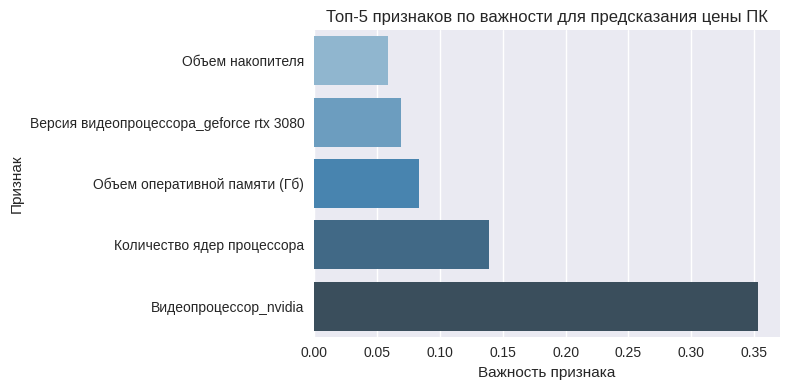

In [ ]:
# Данные о важности признаков
feature_importance = {
    'Видеопроцессор_nvidia': 0.35285694561773173,
    'Количество ядер процессора': 0.1392504652714749,
    'Объем оперативной памяти (Гб)': 0.08368803029953403,
    'Объем накопителя': 0.05917603676905669,
    'Версия видеопроцессора_geforce rtx 3080': 0.06880221925662203
}

# Преобразуем в DataFrame для удобства
import pandas as pd
fi_df = pd.DataFrame(list(feature_importance.items()), columns=['Признак', 'Важность'])

# Сортировка по важности
fi_df = fi_df.sort_values('Важность', ascending=True)

# Визуализация
plt.figure(figsize=(8, 4))
sns.barplot(x='Важность', y='Признак', data=fi_df, palette='Blues_d')
plt.title('Топ-5 признаков по важности для предсказания цены ПК')
plt.xlabel('Важность признака')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()


## Загрузка модели

Сохраним модель, если будет необходимость применять ее вдальнейшем.

In [ ]:
from joblib import dump, load

dump(result_best_model, 'model_for_predicting_computer_prices.joblib')

loaded_model = load('model_for_predicting_computer_prices.joblib')

# Итоговый вывод к работе и рекомендации заказчику

**Ввывод:**

1. Цена возрастает с улучшением характеристик, тогда как популярность напротив, снижается, что может быть связано с повышением цены. Наиболее популярные комлектующие находятся в среднем (а то и низком) ценовом диапазоне.

2. Модель подтверждает, что факторами, влияющими на цену, являются технические характеристики, такие как количество ядер процессора, объем оперативной памяти,объем накопителя, а также конкретные модели ПК с видеопроцессором NVIDIA и версией видеопроцессора Geforce RTX 3080.